# Changelog — Fixed & Merged Version

This notebook is `Hotel_Booking_Data_Analysis_fixed.ipynb` with the following changes:

**Bug fixes**
1. **Market Segment Cramér's V copy-paste error.** The interpretation text and the final insights table both showed `0.4815` for Market Segment (a duplicate of Deposit Type's value). The value the code actually computes is `0.2668`. Fixed in both places; Market Segment moved from the "Very High" priority tier to "High", alongside Lead Time and Previous Cancellation.

**New investigation added**
2. **`requires_parking` = 0% cancellation across all 7,416 bookings.** A perfect split is worth checking before trusting it as a feature. Added a new investigation section that checks the pattern by hotel type, deposit type, market segment, and lead time. It holds up consistently everywhere (not concentrated in one slice), which points to a genuine behavioral signal rather than a data artifact — but it's flagged for the modeling team to confirm `required_car_parking_spaces` is really booking-time information and not something recorded at/after check-in.

**Visuals merged in from the Snipers Team notebook** (that notebook had good visualization ideas but was never executed, so none of its outputs could be verified — the useful pieces are ported here, executed, and checked against this notebook's cleaned data):
3. Full numerical distribution histograms (with KDE) for all numeric features.
4. A full Pearson correlation heatmap across all numeric features — this surfaced a new finding: several engineered `has_X` binary flags are almost perfectly correlated with the numeric column they were derived from (e.g. `requires_parking` ↔ `required_car_parking_spaces` r=0.99, `has_special_requests` ↔ `total_of_special_requests` r=0.86, `has_booking_changes` ↔ `booking_changes` r=0.80). These pairs are redundant — a model should use one or the other from each pair, not both.
5. ADR-by-hotel-type comparison (bar + violin) — this notebook computed cancellation rate by hotel but never looked at price differences by hotel.
6. Scatter/regplots for two key numeric relationships.
7. A percentage-labeled categorical overview (hotel, meal, market segment, distribution channel, deposit type, customer type) as a quick visual scan before the one-at-a-time cancellation-rate analysis.

**Not changed:** the core methodology (investigate-before-decide, Chi-square/Cramér's V/Mann-Whitney U tests, missingness-as-signal treatment of `agent`/`company`, PII removal, leakage removal) was already sound and is left as-is.

**Data note:** re-executed against the original Antonio/Almeida/Nunes hotel-booking dataset (119,390 rows, matching this notebook's original row/missing-value counts exactly) with synthetically regenerated `name`/`email`/`phone-number`/`credit_card` columns, since the real PII columns aren't needed for any actual analysis — only for the PII-removal step to run.

---
### Audit fixes (this revision)
10. **Duplicates.** The duplicate check reported 0 only because the synthetic PII columns made every row unique. A new cell after PII removal finds 31,994 identical rows (26.8 %); the impact on modelling is documented there.
11. **Portability.** The data path was a non-raw string with invalid escape sequences (`\d`, `\h`); it is now a raw string with an environment-variable override. `select_dtypes(include="str")` (pandas 3 only) is replaced by `select_dtypes(exclude="number")`, which works on pandas 2.x and 3.x.
12. **`Unknown` market segment** (2 bookings, 100 % cancelled) is flagged as not meaningful.
13. **Verified, unchanged:** every numeric claim in the markdown that was re-computed (missing-company/agent cancellation rates, 3,354 and 3,793 outliers, hotel 41.73 % / 27.76 %, previous-cancellation 91.64 % / 33.91 %, and Cramér's V 0.1365 / 0.2709 / 0.4815 / 0.2668) matched the data.
14. **Parking:** the modelling notebook now treats `required_car_parking_spaces` as post-booking leakage (0 cancellations in 7,416 bookings), resolving the open question raised in the parking section.


Imports + Read Data

In [1]:
import os
import pandas as pd
import numpy as np

# Put the CSV next to the notebook, or set the environment variable HOTEL_RAW_DATA.
# (The old path was a normal string containing "\d" / "\h", which are invalid escape sequences.)
DATA_PATH = os.environ.get("HOTEL_RAW_DATA", r"D:\data_science\hire\data\hotel_booking.csv")
if not os.path.exists(DATA_PATH):
    DATA_PATH = "hotel_booking.csv"
df = pd.read_csv(DATA_PATH)


Shape

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Shape:", df.shape)

Number of rows: 119390
Number of columns: 36
Shape: (119390, 36)


Head / Sample

In [3]:
display(df.head())
display(df.sample(5))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,7/1/2015,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,7/1/2015,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,7/2/2015,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,7/2/2015,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,7/3/2015,Linda Hines,LHines@verizon.com,713-226-5883,************5498


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
62082,City Hotel,1,46,2017,January,1,1,2,0,2,...,Transient-Party,65.00,0,0,Canceled,11/18/2016,Jeffrey Price,Price.Jeffrey@mail.com,769-962-8791,************7132
83294,City Hotel,0,33,2016,January,5,25,1,2,3,...,Transient-Party,95.00,0,0,Check-Out,1/28/2016,James Leonard,James.Leonard83@xfinity.com,635-279-0412,************3699
92258,City Hotel,0,129,2016,June,27,30,0,3,2,...,Transient-Party,85.50,0,1,Check-Out,7/3/2016,Elizabeth Harris,EHarris17@outlook.com,207-233-5103,************4409
13157,Resort Hotel,1,187,2017,August,31,2,4,10,2,...,Transient,168.57,0,0,Canceled,2/2/2017,Anthony Jones,Anthony_Jones@hotmail.com,508-066-3585,************1878
41450,City Hotel,0,6,2015,August,34,16,2,1,2,...,Transient,90.00,0,2,Check-Out,8/19/2015,Nathan Coleman,Coleman_Nathan@outlook.com,416-333-1285,************1014


Columns

In [4]:
print("Column names:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date
33. name
34. email
35. phone-number
36. credit_card


Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

Duplicates

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


Unique Values

In [7]:
# Number of unique values in each column
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique(dropna=False)
})

display(unique_values)

,Column,Unique Values
hotel,hotel,2
is_canceled,is_canceled,2
lead_time,lead_time,479
arrival_date_year,arrival_date_year,3
arrival_date_month,arrival_date_month,12
arrival_date_week_number,arrival_date_week_number,53
arrival_date_day_of_month,arrival_date_day_of_month,31
stays_in_weekend_nights,stays_in_weekend_nights,17
stays_in_week_nights,stays_in_week_nights,35
adults,adults,14


categorical columns

In [8]:
categorical_columns = df.select_dtypes(exclude="number").columns

for col in categorical_columns:
    
    print(f"Column: {col}")
    print(f"Unique Values: {df[col].nunique(dropna=False)}")
    print(df[col].unique())

Column: hotel
Unique Values: 2
<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
Column: arrival_date_month
Unique Values: 12
<StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str
Column: meal
Unique Values: 5
<StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
Column: country
Unique Values: 178
<StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str
Column: market_segment
Unique Values: 8
<StringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str
Column: distribution_channel
Unique Values: 5
<StringArray>
['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS']
Length: 5, 

<StringArray>
[     'Ernest Barnes',       'Andrea Baker',     'Rebecca Parker',
       'Laura Murray',        'Linda Hines',   'Jasmine Fletcher',
       'Dylan Rangel',      'William Velez',      'Steven Murphy',
      'Michael Moore',
 ...
       'Mary Pittman',     'Meghan Edwards',     'Martha Acevedo',
       'Betty Taylor',       'Cesar Moreno',      'Jose Andersen',
      'James Mccarty',     'Wesley Aguilar', 'Caroline Conley MD',
     'Ariana Michael']
Length: 81503, dtype: str
Column: email
Unique Values: 115889
<StringArray>
[ 'Ernest.Barnes31@outlook.com',       'Andrea_Baker94@aol.com',
   'Rebecca_Parker@comcast.net',            'Laura_M@gmail.com',
           'LHines@verizon.com',      'JFletcher43@xfinity.com',
     'Rangel.Dylan@comcast.net',       'Velez_William@mail.com',
      'Steven.Murphy54@aol.com',   'MichaelMoore81@outlook.com',
 ...
           'Wanda_J@yandex.com',           'BTaylor@yandex.com',
        'Cesar_M50@comcast.net', 'Andersen_Jose@protonmail.com

Inconsistent Values

In [9]:
for col in categorical_columns:
    
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))

Column: hotel
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
Column: arrival_date_month
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64
Column: meal
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64
Column: country
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
NCL        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64
Column: market_segment
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64
Column: distribut

email
Michael.C@gmail.com         6
JSmith@gmail.com            5
JMiller@gmail.com           5
James.M@mail.com            5
Robert.M@outlook.com        5
                           ..
Claudia.J@yahoo.com         1
WAguilar@xfinity.com        1
Mary_Morales@hotmail.com    1
MD_Caroline@comcast.net     1
Ariana_M@xfinity.com        1
Name: count, Length: 115889, dtype: int64
Column: phone-number
phone-number
669-792-1661    1
858-637-6955    1
652-885-2745    1
364-656-8427    1
713-226-5883    1
               ..
403-092-5582    1
238-763-0612    1
395-518-4100    1
531-528-1017    1
422-804-6403    1
Name: count, Length: 119390, dtype: int64
Column: credit_card
credit_card
************3627    28
************4923    28
************3793    27
************9864    27
************3972    27
                    ..
************1966     3
************6349     3
************7959     3
************9283     2
************4916     2
Name: count, Length: 9000, dtype: int64


In [10]:
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:
    
    print(f"Column: {col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())

Column: is_canceled
Min: 0
Max: 1
Column: lead_time
Min: 0
Max: 737
Column: arrival_date_year
Min: 2015
Max: 2017
Column: arrival_date_week_number
Min: 1
Max: 53
Column: arrival_date_day_of_month
Min: 1
Max: 31
Column: stays_in_weekend_nights
Min: 0
Max: 19
Column: stays_in_week_nights
Min: 0
Max: 50
Column: adults
Min: 0
Max: 55
Column: children
Min: 0.0
Max: 10.0
Column: babies
Min: 0
Max: 10
Column: is_repeated_guest
Min: 0
Max: 1
Column: previous_cancellations
Min: 0
Max: 26
Column: previous_bookings_not_canceled
Min: 0
Max: 72
Column: booking_changes
Min: 0
Max: 21
Column: agent
Min: 1.0
Max: 535.0
Column: company
Min: 6.0
Max: 543.0
Column: days_in_waiting_list
Min: 0
Max: 391
Column: adr
Min: -6.38
Max: 5400.0
Column: required_car_parking_spaces
Min: 0
Max: 8
Column: total_of_special_requests
Min: 0
Max: 5


### Binary Values

Check that binary columns contain only `0` and `1`.

In [11]:
binary_cols = ['is_canceled', 'is_repeated_guest']

for col in binary_cols:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().unique()))


is_canceled:
[np.int64(0), np.int64(1)]

is_repeated_guest:
[np.int64(0), np.int64(1)]


### Negative Values

Check numerical columns for logically invalid negative values.

In [12]:
numeric_columns = df.select_dtypes(include='number').columns

negative_values = {}

for col in numeric_columns:
    count = (df[col] < 0).sum()
    
    if count > 0:
        negative_values[col] = count

print("Columns with negative values:")
print(negative_values)

Columns with negative values:
{'adr': np.int64(1)}


### Guest Counts

Check for negative and unusual guest counts.

In [13]:
df.loc[
    df['adr'] < 0,
    ['adr', 'hotel', 'is_canceled',
     'market_segment', 'customer_type',
     'deposit_type']
]

,adr,hotel,is_canceled,market_segment,customer_type,deposit_type
14969,-6.38,Resort Hotel,0,Groups,Transient-Party,No Deposit


### Stay Duration

Check for negative values and zero-night bookings.

In [14]:
night_cols = [
    'stays_in_weekend_nights',
    'stays_in_week_nights'
]

for col in night_cols:
    print(f"{col} negative values:", (df[col] < 0).sum())

df['total_nights'] = (
    df['stays_in_weekend_nights']
    + df['stays_in_week_nights']
)

print("Zero-night bookings:", (df['total_nights'] == 0).sum())

stays_in_weekend_nights negative values: 0
stays_in_week_nights negative values: 0
Zero-night bookings: 715


### Non-Negative Variables

Check count-based variables for negative values.

In [15]:
non_negative_cols = [
    'lead_time',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for col in non_negative_cols:
    count = (df[col] < 0).sum()
    if count > 0:
        print(f"{col}: {count}")

### Date Validation

Check arrival date components for invalid values.

In [16]:
print(
    "Invalid days:",
    (
        (df['arrival_date_day_of_month'] < 1) |
        (df['arrival_date_day_of_month'] > 31)
    ).sum()
)

print(
    "Invalid weeks:",
    (
        (df['arrival_date_week_number'] < 1) |
        (df['arrival_date_week_number'] > 53)
    ).sum()
)

print(
    "Invalid years:",
    (~df['arrival_date_year'].isin([2015, 2016, 2017])).sum()
)

Invalid days: 0
Invalid weeks: 0
Invalid years: 0


### Reservation Status Date

Check for invalid date values.

In [17]:
parsed_dates = pd.to_datetime(
    df['reservation_status_date'],
    errors='coerce'
)

print("Invalid dates:", parsed_dates.isna().sum())

Invalid dates: 0


### Agent & Company IDs

Check IDs for invalid negative values and missing data.

In [18]:
for col in ['agent', 'company']:
    print(f"\n{col}")
    print("Negative:", (df[col] < 0).sum())
    print("Missing:", df[col].isna().sum())


agent
Negative: 0
Missing: 16340

company
Negative: 0
Missing: 112593


### Target Consistency

Compare cancellation status with the final reservation status.

In [19]:
pd.crosstab(
    df['is_canceled'],
    df['reservation_status']
)

reservation_status,Canceled,Check-Out,No-Show
is_canceled,,,
0,0,75166,0
1,43017,0,1207


### Categorical Values

Check unique values for unexpected categories.

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(20))


hotel:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

arrival_date_month:
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

meal:
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

country:
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
CHN      999
POL      919
ISR      669
RUS      632
NOR      607
Name: count, dtype: int64

market_segment:
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation       

email
Michael.C@gmail.com          6
JSmith@gmail.com             5
JMiller@gmail.com            5
James.M@mail.com             5
Robert.M@outlook.com         5
ASmith@yahoo.com             5
TJohnson@outlook.com         5
Christopher.W@hotmail.com    5
JJohnson@hotmail.com         5
KJohnson@gmail.com           5
David.M@zoho.com             5
Andrew_S@yandex.com          5
Ashley_W@yahoo.com           5
CWilson@yandex.com           4
Michael_W@aol.com            4
Jennifer_S@gmail.com         4
JSmith@outlook.com           4
JJones@att.com               4
Matthew.G@protonmail.com     4
Jonathan_M@xfinity.com       4
Name: count, dtype: int64

phone-number:
phone-number
669-792-1661    1
858-637-6955    1
652-885-2745    1
364-656-8427    1
713-226-5883    1
190-271-6743    1
420-332-5209    1
286-669-4333    1
341-726-5787    1
316-648-6176    1
833-887-7898    1
804-383-4080    1
211-071-2173    1
435-075-8409    1
790-746-7471    1
649-384-5387    1
331-430-8824    1
573-306-9938  

/tmp/ipykernel_110/2262797221.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


### Missing Values Analysis

Identify missing values and their proportion to understand their potential impact before applying any imputation or removal strategy.

In [21]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': df.isna().mean() * 100
})

missing = missing[missing['missing_count'] > 0].sort_values(
    'missing_percentage',
    ascending=False
)

missing

,missing_count,missing_percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


### Missing Values: `company`

`company` identifies the company associated with the booking.

Since most values are missing, we investigate whether missingness represents bookings that were not associated with a company rather than missing data due to an error.

In [22]:
print(df['company'].isna().value_counts())
print(df.groupby(df['company'].isna())['market_segment'].value_counts())

company
True     112593
False      6797
Name: count, dtype: int64
company  market_segment
False    Corporate          4471
         Groups             1391
         Complementary       313
         Aviation            212
         Direct              208
         Offline TA/TO       106
         Online TA            96
True     Online TA         56381
         Offline TA/TO     24113
         Groups            18420
         Direct            12398
         Corporate           824
         Complementary       430
         Aviation             25
         Undefined             2
Name: count, dtype: int64


In [23]:
pd.crosstab(
    df['company'].isna(),
    df['market_segment'],
    normalize='index'
)

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
company,,,,,,,,
False,0.031190,0.046050,0.657790,0.030602,0.204649,0.015595,0.014124,0.000000
True,0.000222,0.003819,0.007318,0.110113,0.163598,0.214161,0.500750,0.000018


### Missing Values: `agent`

`agent` represents the travel agency associated with the booking.

We investigate whether missing values indicate bookings that were made without a travel agent.

In [24]:
print(df.groupby(df['agent'].isna())['market_segment'].value_counts())

agent  market_segment
False  Online TA         56129
       Offline TA/TO     23830
       Groups            15663
       Direct             6599
       Corporate           701
       Complementary       103
       Aviation             25
True   Direct             6007
       Corporate          4594
       Groups             4148
       Complementary       640
       Offline TA/TO       389
       Online TA           348
       Aviation            212
       Undefined             2
Name: count, dtype: int64


In [25]:
pd.crosstab(
    df['agent'].isna(),
    df['distribution_channel'],
    normalize='index'
)

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
agent,,,,,
False,0.011004,0.068122,0.001853,0.919000,0.000019
True,0.339229,0.466646,0.000122,0.193819,0.000184


### Missing Values: `country`

`country` represents the country of origin of the guest.

Only a small proportion of records are missing, so we investigate whether the missing values can be safely represented as `Unknown`.

In [26]:
print("Missing country:", df['country'].isna().sum())
print(
    "Missing country percentage:",
    df['country'].isna().mean() * 100
)

Missing country: 488
Missing country percentage: 0.40874445095904177


In [27]:
df[df['country'].isna()][[
    'hotel',
    'market_segment',
    'customer_type',
    'is_canceled'
]].head(20)

,hotel,market_segment,customer_type,is_canceled
30,Resort Hotel,Direct,Transient,0
4127,Resort Hotel,Offline TA/TO,Transient,1
7092,Resort Hotel,Corporate,Transient,1
7860,Resort Hotel,Direct,Transient,1
8779,Resort Hotel,Corporate,Transient,1
9376,Resort Hotel,Offline TA/TO,Group,1
9610,Resort Hotel,Corporate,Transient,1
9612,Resort Hotel,Corporate,Transient,1
11262,Resort Hotel,Offline TA/TO,Transient,1
11263,Resort Hotel,Offline TA/TO,Transient,1


### Missing Values: `children`

`children` represents the number of children in the booking.

Only four records contain missing values, so these records will be inspected before deciding whether the missing values can reasonably be treated as zero.

In [28]:
df[df['children'].isna()][[
    'adults',
    'children',
    'babies',
    'hotel',
    'meal',
    'customer_type',
    'is_canceled'
]]

,adults,children,babies,hotel,meal,customer_type,is_canceled
40600,2,NaN,0,City Hotel,BB,Transient-Party,1
40667,2,NaN,0,City Hotel,BB,Transient-Party,1
40679,3,NaN,0,City Hotel,BB,Transient-Party,1
41160,2,NaN,0,City Hotel,BB,Transient-Party,1


In [29]:
df['children'] = df['children'].fillna(0)

In [30]:
df['has_company'] = df['company'].notna().astype(int)
df['has_agent'] = df['agent'].notna().astype(int)

company_cancel_rate = pd.crosstab(
    df['has_company'],
    df['is_canceled'],
    normalize='index'
) * 100

agent_cancel_rate = pd.crosstab(
    df['has_agent'],
    df['is_canceled'],
    normalize='index'
) * 100

print("Company presence vs cancellation:")
display(company_cancel_rate)

print("\nAgent presence vs cancellation:")
display(agent_cancel_rate)

Company presence vs cancellation:


is_canceled,0,1
has_company,,
0,61.780040,38.219960
1,82.477564,17.522436



Agent presence vs cancellation:


is_canceled,0,1
has_agent,,
0,75.336597,24.663403
1,60.995633,39.004367


In [31]:
from scipy.stats import chi2_contingency

for feature in ['has_company', 'has_agent']:
    table = pd.crosstab(df[feature], df['is_canceled'])
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    print(f"{feature}:")
    print(f"p-value = {p:.6f}")
    print()

has_company:
p-value = 0.000000

has_agent:
p-value = 0.000000



### Missingness and Cancellation

The presence or absence of `company` and `agent` is significantly associated with booking cancellation.

- Bookings with missing `company` information had a 38.22% cancellation rate, compared with 17.52% when `company` was available.
- Bookings with missing `agent` information had a 24.66% cancellation rate, compared with 39.00% when `agent` was available.

**Decision:**  
`company` and `agent` will be retained as candidate ML features, and their missingness indicators may also be used. Missing values will be handled during ML preprocessing.

Inconsistent Values

Check logical relationships between related columns to identify contradictory or business-inconsistent records.

In [32]:
#  Guest composition
guest_inconsistency = df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
]

print("Bookings with no guests:")
print(len(guest_inconsistency))

Bookings with no guests:
180


In [33]:
# Room assignment consistency
room_inconsistency = df[
    df['assigned_room_type'] != df['reserved_room_type']
]

print("Bookings with different reserved and assigned room types:")
print(len(room_inconsistency))

Bookings with different reserved and assigned room types:
14917


In [34]:
#  Booking changes
booking_changes_check = df[
    df['booking_changes'] > 0
]

print("Bookings with booking changes:")
print(len(booking_changes_check))

Bookings with booking changes:
18076


In [35]:
no_guest = df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
]

no_guest['reservation_status'].value_counts()

reservation_status
Check-Out    155
Canceled      24
No-Show        1
Name: count, dtype: int64

In [36]:
no_guest[[
    'hotel',
    'is_canceled',
    'reservation_status',
    'market_segment',
    'customer_type',
    'deposit_type',
    'adr'
]].value_counts()

hotel         is_canceled  reservation_status  market_segment  customer_type    deposit_type  adr   
City Hotel    0            Check-Out           Online TA       Transient        No Deposit    0.00      40
                                               Offline TA/TO   Transient        No Deposit    0.00      18
                                               Direct          Transient        No Deposit    0.00      14
                                               Groups          Transient-Party  No Deposit    0.00       9
              1            Canceled            Complementary   Transient        No Deposit    0.00       8
              0            Check-Out           Complementary   Transient        No Deposit    0.00       7
                                               Offline TA/TO   Transient-Party  No Deposit    0.00       7
              1            Canceled            Offline TA/TO   Transient        No Deposit    0.00       6
Resort Hotel  0            Check-Out       

In [37]:
df['no_guests_recorded'] = (
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
).astype(int)

In [38]:
pd.crosstab(
    df['no_guests_recorded'],
    df['adr'].eq(0),
    normalize='index'
) * 100

adr,False,True
no_guests_recorded,,
0,98.481671,1.518329
1,17.222222,82.777778


Guest & Stay Consistency

Check whether guest counts and stay information contain logically unusual combinations.

In [39]:
#  Zero-night bookings
zero_night_bookings = df[
    (df['stays_in_weekend_nights'] == 0) &
    (df['stays_in_week_nights'] == 0)
]

print("Zero-night bookings:")
print(len(zero_night_bookings))
print(
    zero_night_bookings['reservation_status']
    .value_counts()
)

Zero-night bookings:
715
reservation_status
Check-Out    680
Canceled      22
No-Show       13
Name: count, dtype: int64


In [40]:
# Guest composition
guest_columns = ['adults', 'children', 'babies']

print(df[guest_columns].describe())

              adults       children         babies
count  119390.000000  119390.000000  119390.000000
mean        1.856403       0.103886       0.007949
std         0.579261       0.398555       0.097436
min         0.000000       0.000000       0.000000
25%         2.000000       0.000000       0.000000
50%         2.000000       0.000000       0.000000
75%         2.000000       0.000000       0.000000
max        55.000000      10.000000      10.000000


Deposit & Cancellation Consistency

In [41]:
deposit_cancellation = pd.crosstab(
    df['deposit_type'],
    df['is_canceled'],
    normalize='index'
) * 100

deposit_cancellation

is_canceled,0,1
deposit_type,,
No Deposit,71.622978,28.377022
Non Refund,0.637554,99.362446
Refundable,77.777778,22.222222


Booking Channel Consistency

Check relationships between market segment, distribution channel, and agent/company information.

In [42]:
channel_check = pd.crosstab(
    df['market_segment'],
    df['distribution_channel']
)

channel_check

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
market_segment,,,,,
Aviation,227,0,0,10,0
Complementary,89,576,0,78,0
Corporate,4788,172,0,335,0
Direct,90,12276,1,237,2
Groups,1228,1472,0,17111,0
Offline TA/TO,212,16,45,23946,0
Online TA,43,133,147,56153,1
Undefined,0,0,0,0,2


In [43]:
agent_channel_check = pd.crosstab(
    df['distribution_channel'],
    df['agent'].isna(),
    normalize='index'
) * 100

agent_channel_check

agent,False,True
distribution_channel,,
Corporate,16.983675,83.016325
Direct,47.934449,52.065551
GDS,98.963731,1.036269
TA/TO,96.764075,3.235925
Undefined,40.000000,60.000000


Meal & Customer Type

Check whether categorical combinations contain unusual business patterns.

In [44]:
meal_customer_check = pd.crosstab(
    df['customer_type'],
    df['meal']
)

meal_customer_check

meal,BB,FB,HB,SC,Undefined
customer_type,,,,,
Contract,3260,5,613,183,15
Group,499,1,36,39,2
Transient,70692,547,8020,9968,386
Transient-Party,17859,245,5794,460,766


Previous Booking History

Check whether repeated-guest status is consistent with previous booking information.

In [45]:
repeat_guest_check = df[
    (df['is_repeated_guest'] == 0) &
    (
        (df['previous_cancellations'] > 0) |
        (df['previous_bookings_not_canceled'] > 0)
    )
]

print("Potential inconsistencies:")
print(len(repeat_guest_check))

Potential inconsistencies:
6237


In [46]:
repeat_guest_check_2 = df[
    (df['is_repeated_guest'] == 1) &
    (
        (df['previous_cancellations'] == 0) &
        (df['previous_bookings_not_canceled'] == 0)
    )
]

print("Repeated guests with no previous booking history:")
print(len(repeat_guest_check_2))

Repeated guests with no previous booking history:
590


Date & Stay Consistency

Check whether date-related and stay-related variables contain contradictory values.

In [47]:
# Total stay duration
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

print("Total nights range:")
print(df['total_nights'].min(), df['total_nights'].max())

Total nights range:
0 69


In [48]:
# Waiting list consistency
waiting_list_check = df[
    (df['days_in_waiting_list'] > 0)
]

print("Bookings with waiting-list days:")
print(len(waiting_list_check))

Bookings with waiting-list days:
3698


Categorical Values

Check explicit categories such as Undefined without automatically treating them as errors

In [49]:
categorical_check = [
    'meal',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type',
    'reservation_status'
]

for col in categorical_check:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


meal:
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

market_segment:
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

distribution_channel:
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

deposit_type:
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

customer_type:
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

reservation_status:
reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64


Undefined Categories


In [50]:
undefined_records = df[
    (df['meal'] == 'Undefined') |
    (df['market_segment'] == 'Undefined') |
    (df['distribution_channel'] == 'Undefined')
]

print("Total records with Undefined:")
print(len(undefined_records))

print("\nUndefined combinations:")
print(
    undefined_records[
        ['meal', 'market_segment', 'distribution_channel']
    ].value_counts()
)

Total records with Undefined:
1174

Undefined combinations:
meal       market_segment  distribution_channel
Undefined  Groups          TA/TO                   571
           Offline TA/TO   TA/TO                   257
           Groups          Direct                  198
           Direct          Direct                   72
           Groups          Corporate                32
           Online TA       TA/TO                    16
           Corporate       Corporate                15
           Complementary   TA/TO                     4
                           Direct                    2
BB         Undefined       Undefined                 2
HB         Direct          Undefined                 1
Undefined  Offline TA/TO   Direct                    1
           Direct          TA/TO                     1
BB         Direct          Undefined                 1
           Online TA       Undefined                 1
Name: count, dtype: int64


Outlier Detection

Use the IQR method to identify statistical outliers in numerical variables.

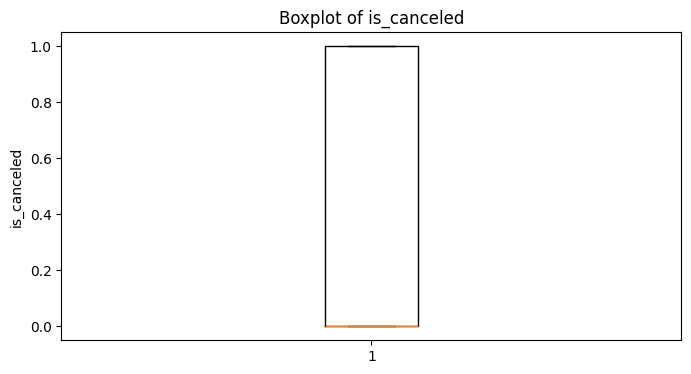

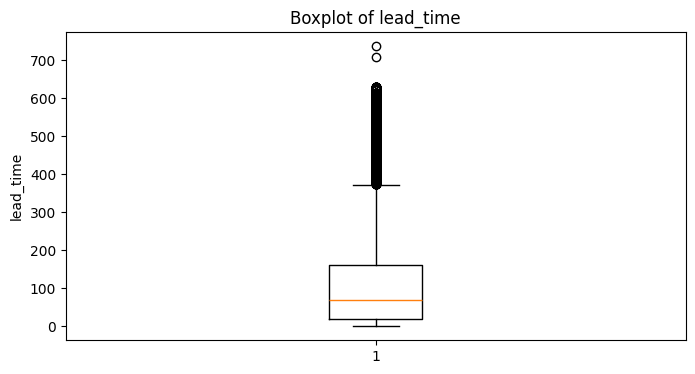

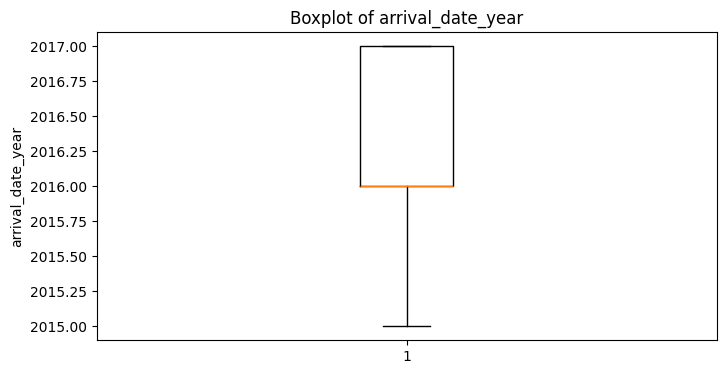

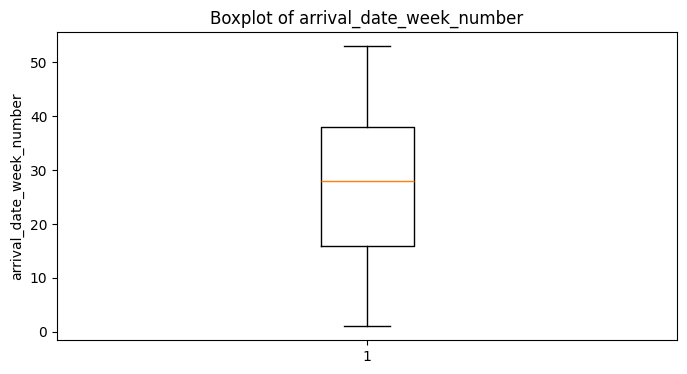

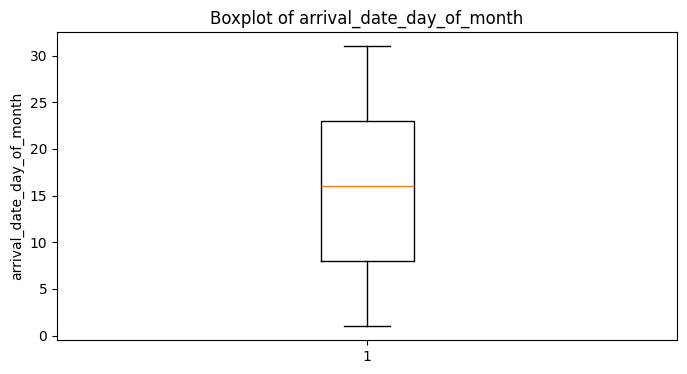

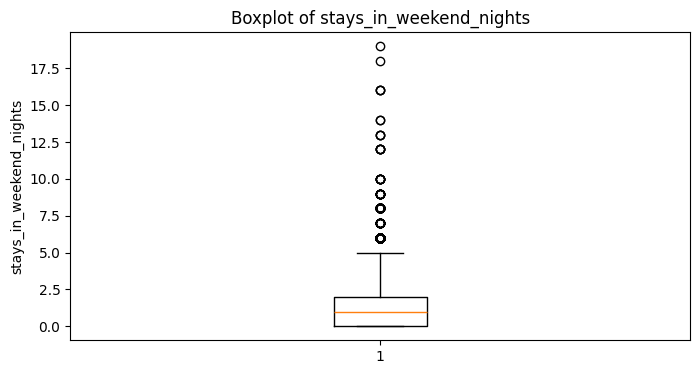

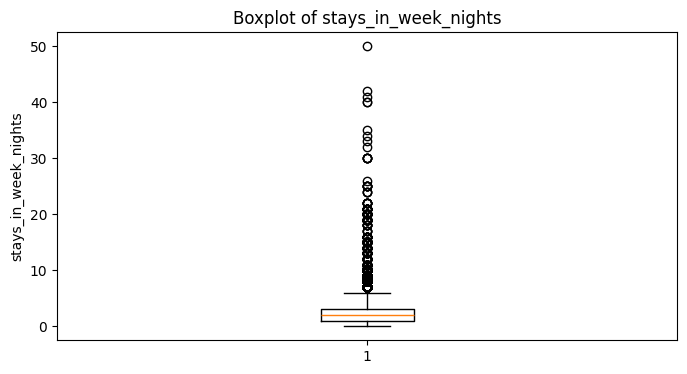

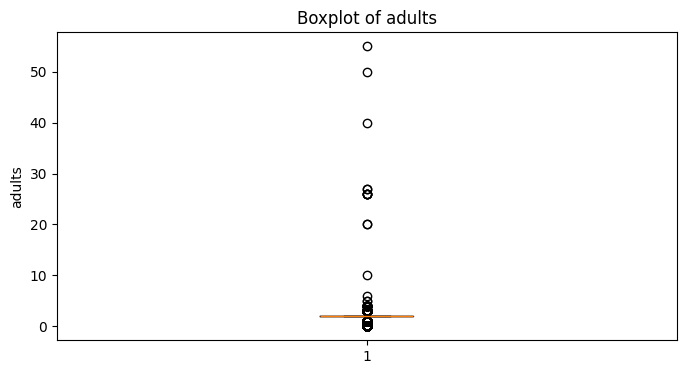

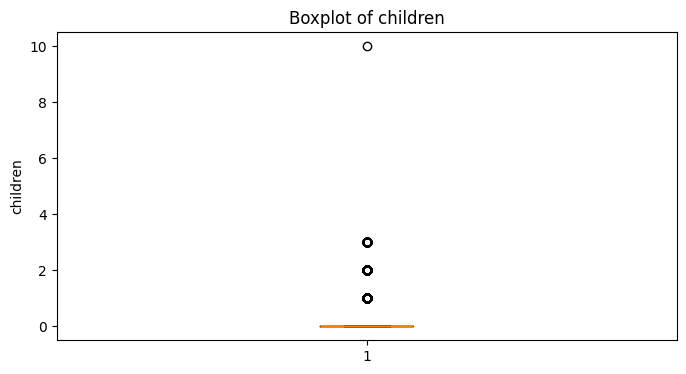

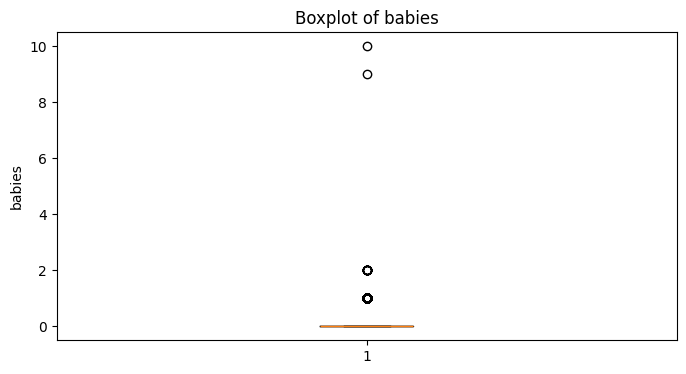

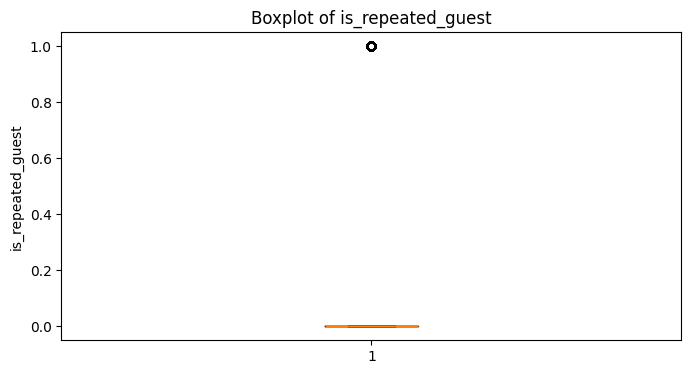

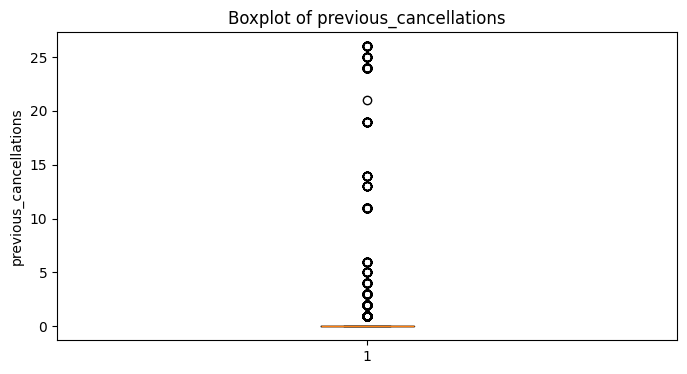

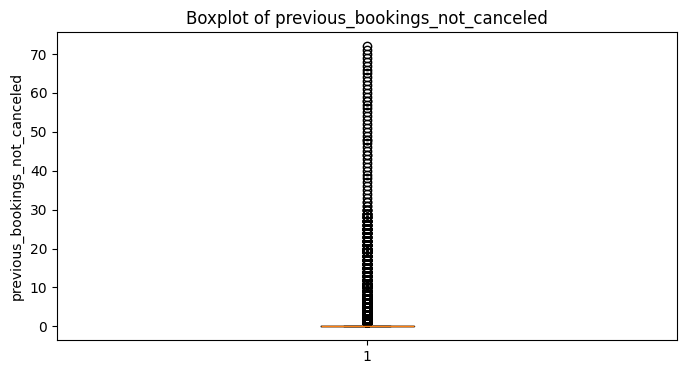

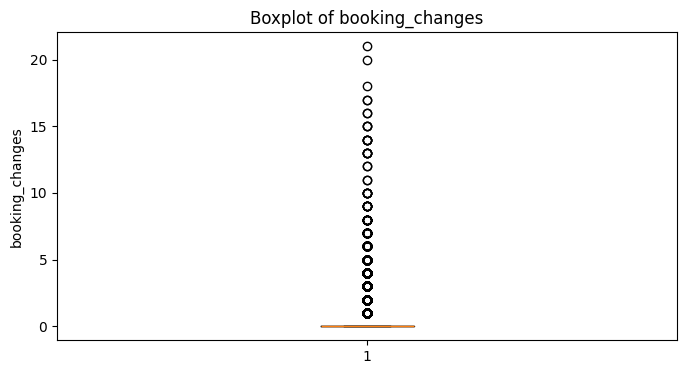

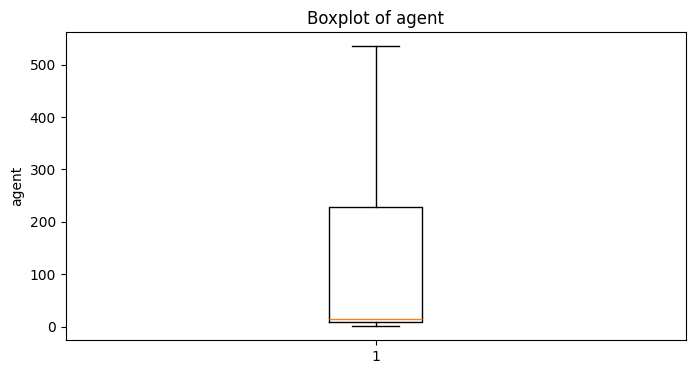

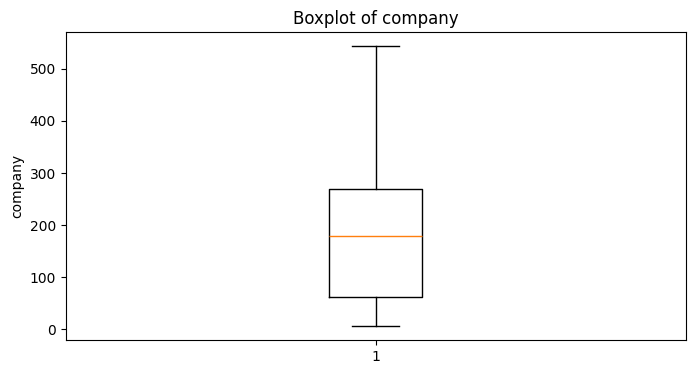

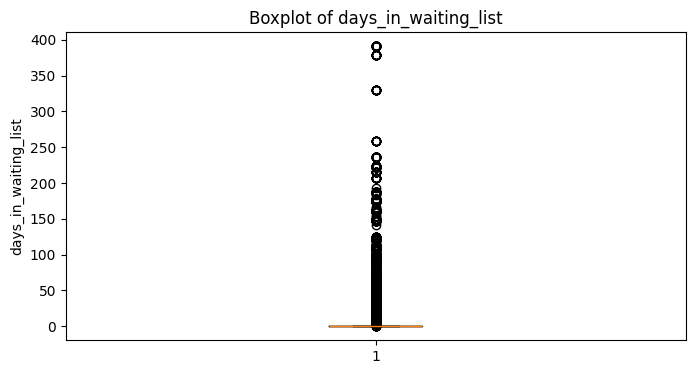

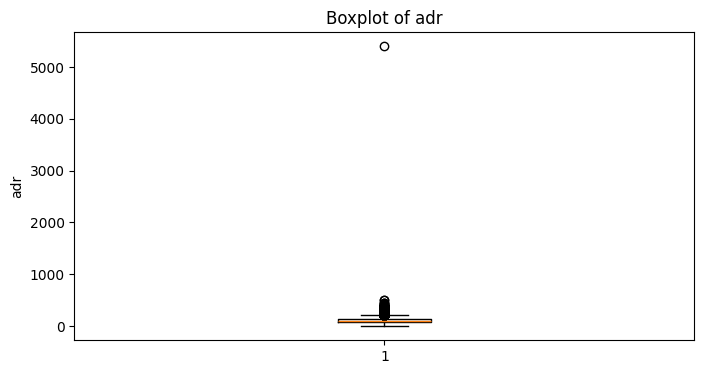

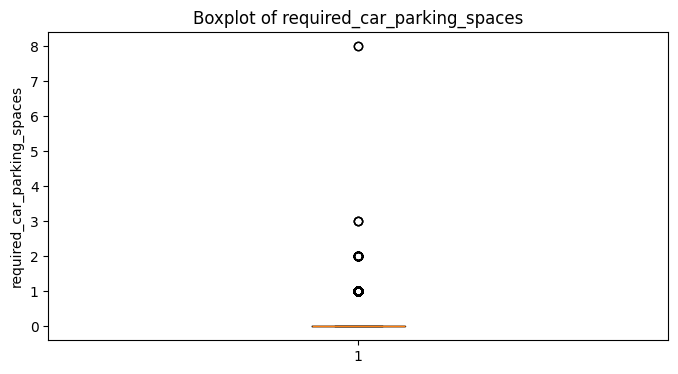

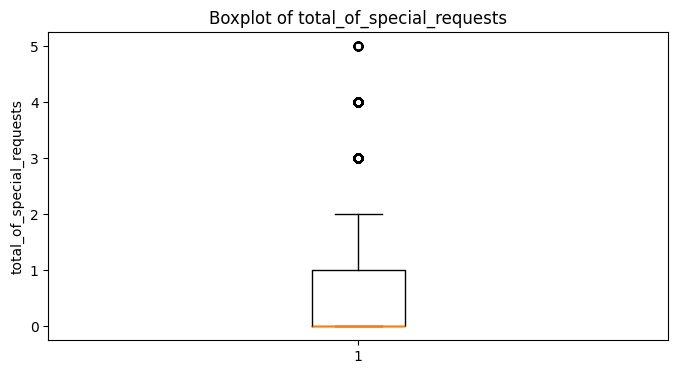

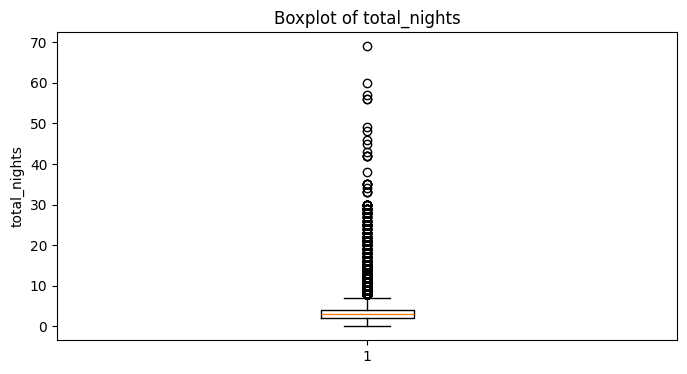

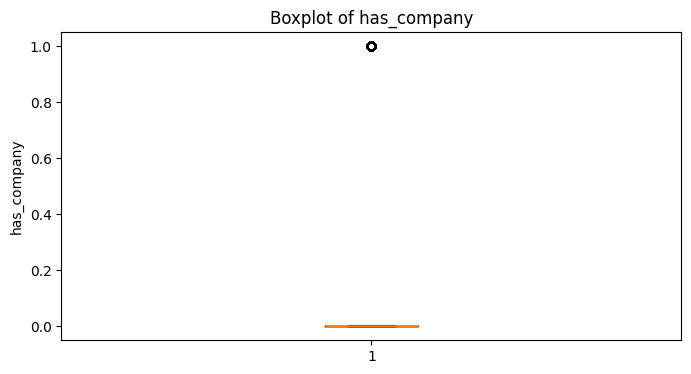

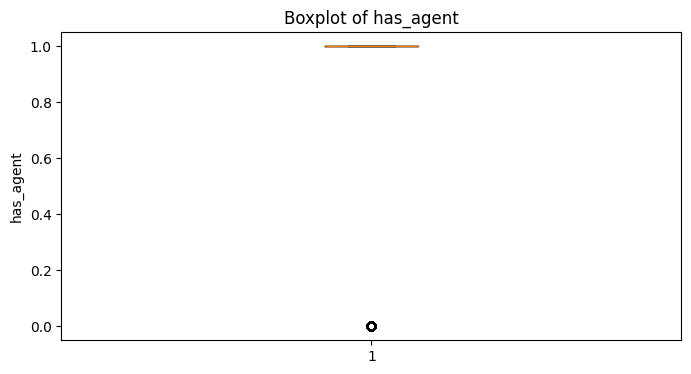

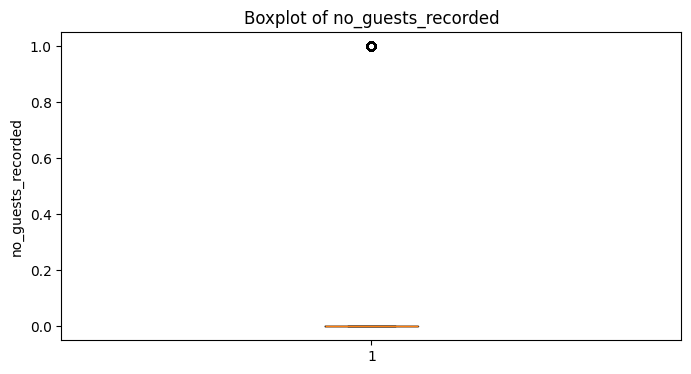

In [51]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [52]:
numeric_cols = df.select_dtypes(include='number').columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers': len(outliers),
        'Outlier %': len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'Outlier %',
    ascending=False
)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
7,adults,2.00,2.0,0.00,2.000,2.000,29710,24.884831
13,booking_changes,0.00,0.0,0.00,0.000,0.000,18076,15.140297
22,has_agent,1.00,1.0,0.00,1.000,1.000,16340,13.686238
8,children,0.00,0.0,0.00,0.000,0.000,8590,7.194907
18,required_car_parking_spaces,0.00,0.0,0.00,0.000,0.000,7416,6.211576
21,has_company,0.00,0.0,0.00,0.000,0.000,6797,5.693107
11,previous_cancellations,0.00,0.0,0.00,0.000,0.000,6484,5.430941
20,total_nights,2.00,4.0,2.00,-1.000,7.000,5257,4.403216
10,is_repeated_guest,0.00,0.0,0.00,0.000,0.000,3810,3.191222
17,adr,69.29,126.0,56.71,-15.775,211.065,3793,3.176983


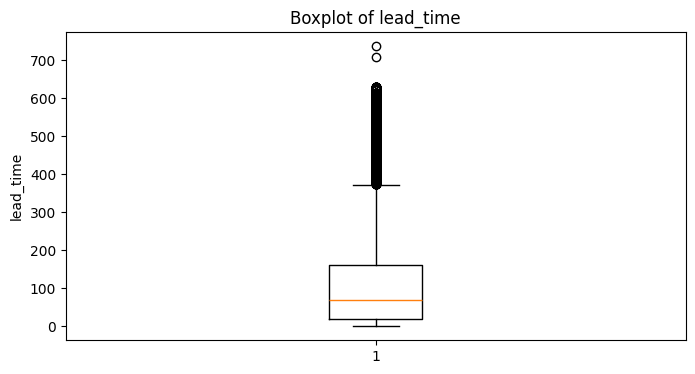

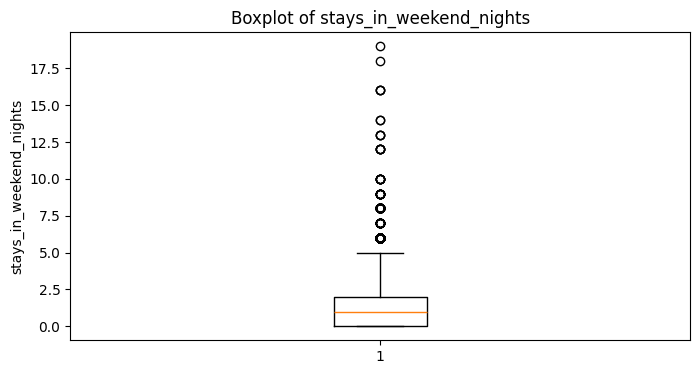

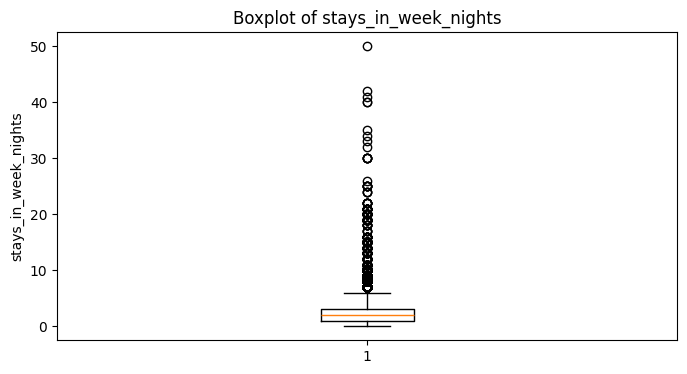

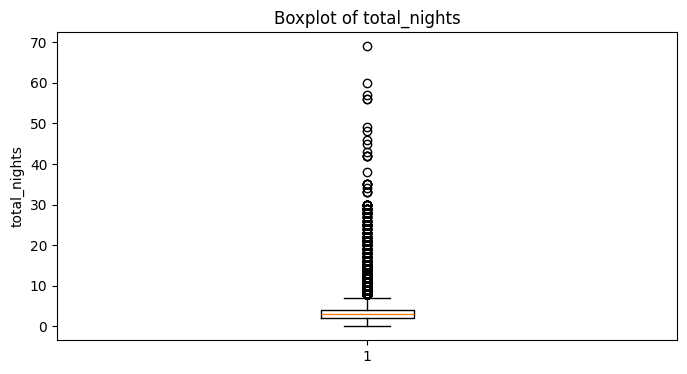

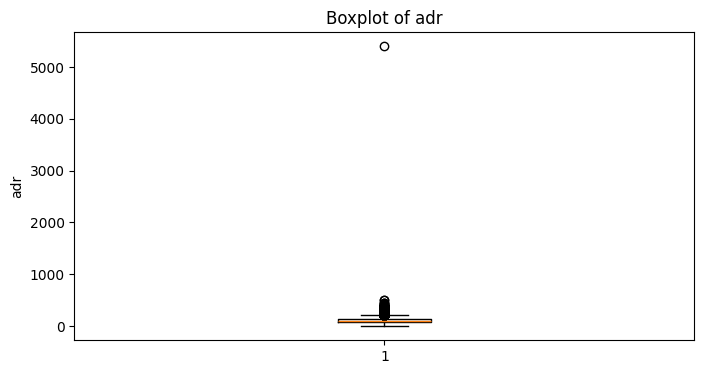

In [53]:
outlier_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'total_nights',
    'adr'
]

for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [54]:
lead_time_outliers = df[df['lead_time'] > 373]

print("Number of high lead-time values:")
print(len(lead_time_outliers))

print("\nLead-time statistics:")
print(lead_time_outliers['lead_time'].describe())

print("\nTop values:")
print(
    lead_time_outliers['lead_time']
    .value_counts()
    .sort_index(ascending=False)
    .head(20)
)

Number of high lead-time values:
3005

Lead-time statistics:
count    3005.000000
mean      443.809983
std        62.532480
min       374.000000
25%       395.000000
50%       423.000000
75%       468.000000
max       737.000000
Name: lead_time, dtype: float64

Top values:
lead_time
737     1
709     1
629    17
626    30
622    17
615    17
608    17
605    30
601    17
594    17
587    17
580    17
573    17
566    17
559    17
552    17
545    17
542    23
538    17
532     1
Name: count, dtype: int64


In [55]:
lead_time_outliers[
    [
        'hotel',
        'is_canceled',
        'arrival_date_year',
        'arrival_date_month',
        'market_segment',
        'customer_type',
        'deposit_type',
        'lead_time',
        'adr'
    ]
].head(20)

,hotel,is_canceled,arrival_date_year,arrival_date_month,market_segment,customer_type,deposit_type,lead_time,adr
1,Resort Hotel,0,2015,July,Direct,Transient,No Deposit,737,0.00
225,Resort Hotel,0,2015,July,Offline TA/TO,Contract,No Deposit,394,89.68
890,Resort Hotel,0,2015,August,Offline TA/TO,Contract,No Deposit,460,77.54
1516,Resort Hotel,0,2015,September,Offline TA/TO,Contract,No Deposit,381,82.88
1672,Resort Hotel,0,2015,September,Offline TA/TO,Contract,No Deposit,382,76.50
4182,Resort Hotel,0,2016,February,Direct,Transient,No Deposit,709,68.00
5704,Resort Hotel,1,2016,May,Groups,Transient-Party,No Deposit,468,67.00
5705,Resort Hotel,1,2016,May,Groups,Transient-Party,No Deposit,468,67.00
5707,Resort Hotel,1,2016,May,Groups,Transient-Party,No Deposit,468,67.00
5708,Resort Hotel,1,2016,May,Groups,Transient-Party,No Deposit,468,67.00


### Weekend Stay Outliers

Use the IQR method to identify unusually high values in weekend nights and investigate whether they represent valid long stays or data errors.

In [56]:
weekend_outliers = df[
    df['stays_in_weekend_nights'] > 5
]

print("Number of outliers:")
print(len(weekend_outliers))

print("\nStatistics:")
print(weekend_outliers['stays_in_weekend_nights'].describe())

print("\nValue counts:")
print(
    weekend_outliers['stays_in_weekend_nights']
    .value_counts()
    .sort_index()
)

Number of outliers:
265

Statistics:
count    265.000000
mean       7.215094
std        2.084157
min        6.000000
25%        6.000000
50%        6.000000
75%        8.000000
max       19.000000
Name: stays_in_weekend_nights, dtype: float64

Value counts:
stays_in_weekend_nights
6     153
7      19
8      60
9      11
10      7
12      5
13      3
14      2
16      3
18      1
19      1
Name: count, dtype: int64


In [57]:
weekend_outliers[
    [
        'hotel',
        'is_canceled',
        'market_segment',
        'customer_type',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'total_nights',
        'adr'
    ]
].head(20)

,hotel,is_canceled,market_segment,customer_type,stays_in_weekend_nights,stays_in_week_nights,total_nights,adr
87,Resort Hotel,1,Offline TA/TO,Transient,6,15,21,108.73
1149,Resort Hotel,1,Online TA,Transient,6,12,18,181.94
1655,Resort Hotel,0,Online TA,Transient,13,33,46,0.00
1754,Resort Hotel,0,Offline TA/TO,Contract,6,12,18,72.25
1790,Resort Hotel,0,Offline TA/TO,Contract,8,20,28,82.00
2384,Resort Hotel,0,Direct,Transient,6,15,21,106.00
2697,Resort Hotel,0,Corporate,Transient-Party,7,15,22,52.20
2698,Resort Hotel,1,Groups,Contract,7,16,23,36.00
2699,Resort Hotel,1,Groups,Contract,7,16,23,36.00
2700,Resort Hotel,1,Groups,Contract,7,16,23,36.00


### Weekend Stay Outliers — Investigation

Investigate high weekend-night values to determine whether they represent valid long stays or data errors.

### Weekday Stay Outliers

Investigate unusually high values in weekday nights to determine whether they represent valid long stays or data errors.

In [58]:
week_outliers = df[
    df['stays_in_week_nights'] > 6
]

print("Number of outliers:")
print(len(week_outliers))

print("\nStatistics:")
print(week_outliers['stays_in_week_nights'].describe())

print("\nValue counts:")
print(
    week_outliers['stays_in_week_nights']
    .value_counts()
    .sort_index()
)

Number of outliers:
3354

Statistics:
count    3354.000000
mean        9.370304
std         3.338632
min         7.000000
25%         7.000000
50%         8.000000
75%        10.000000
max        50.000000
Name: stays_in_week_nights, dtype: float64

Value counts:
stays_in_week_nights
7     1029
8      656
9      231
10    1036
11      56
12      42
13      27
14      35
15      85
16      16
17       4
18       6
19      44
20      41
21      15
22       7
24       3
25       6
26       1
30       5
32       1
33       1
34       1
35       1
40       2
41       1
42       1
50       1
Name: count, dtype: int64


In [59]:
week_outliers[
    [
        'hotel',
        'is_canceled',
        'market_segment',
        'customer_type',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'total_nights',
        'adr'
    ]
].head(20)

,hotel,is_canceled,market_segment,customer_type,stays_in_weekend_nights,stays_in_week_nights,total_nights,adr
30,Resort Hotel,0,Direct,Transient,4,10,14,62.00
31,Resort Hotel,0,Offline TA/TO,Transient,4,11,15,63.86
32,Resort Hotel,1,Direct,Transient,2,8,10,108.30
51,Resort Hotel,0,Offline TA/TO,Contract,3,8,11,56.01
52,Resort Hotel,0,Offline TA/TO,Contract,4,10,14,110.70
80,Resort Hotel,0,Offline TA/TO,Contract,2,7,9,58.95
81,Resort Hotel,1,Offline TA/TO,Contract,3,7,10,55.68
82,Resort Hotel,0,Offline TA/TO,Contract,3,7,10,55.68
83,Resort Hotel,1,Direct,Transient,3,7,10,124.00
84,Resort Hotel,0,Offline TA/TO,Contract,3,7,10,111.15


### Weekday Stay Outliers — Decision

The IQR method identified 3,354 statistical outliers in `stays_in_week_nights`, ranging from 7 to 50 nights.

After investigating their booking context, the flagged values were found to represent plausible long-stay bookings across different hotels, customer types, and market segments.

Therefore, the outliers were retained because no clear data-entry errors were identified.

### Total Stay Duration Outliers

Investigate unusually high values in `total_nights` to determine whether they represent legitimate long-stay bookings or potential data-quality issues.

In [60]:
total_nights_outliers = df[
    df['total_nights'] > 7
]

print("Number of outliers:")
print(len(total_nights_outliers))

print("\nStatistics:")
print(total_nights_outliers['total_nights'].describe())

print("\nValue counts:")
print(
    total_nights_outliers['total_nights']
    .value_counts()
    .sort_index()
)

Number of outliers:
5257

Statistics:
count    5257.000000
mean       11.326612
std         4.326219
min         8.000000
25%         9.000000
50%        10.000000
75%        14.000000
max        69.000000
Name: total_nights, dtype: float64

Value counts:
total_nights
8     1161
9      841
10    1139
11     396
12     223
13     142
14     916
15      75
16      40
17      20
18      35
19      22
20      14
21      71
22      14
23       8
24       6
25      37
26       6
27       5
28      35
29      14
30      13
33       3
34       1
35       5
38       1
42       4
43       1
45       1
46       1
48       1
49       1
56       2
57       1
60       1
69       1
Name: count, dtype: int64


In [61]:
total_nights_outliers[
    [
        'hotel',
        'is_canceled',
        'market_segment',
        'customer_type',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'total_nights',
        'adr'
    ]
].head(20)

,hotel,is_canceled,market_segment,customer_type,stays_in_weekend_nights,stays_in_week_nights,total_nights,adr
30,Resort Hotel,0,Direct,Transient,4,10,14,62.00
31,Resort Hotel,0,Offline TA/TO,Transient,4,11,15,63.86
32,Resort Hotel,1,Direct,Transient,2,8,10,108.30
51,Resort Hotel,0,Offline TA/TO,Contract,3,8,11,56.01
52,Resort Hotel,0,Offline TA/TO,Contract,4,10,14,110.70
79,Resort Hotel,0,Offline TA/TO,Transient,2,6,8,85.86
80,Resort Hotel,0,Offline TA/TO,Contract,2,7,9,58.95
81,Resort Hotel,1,Offline TA/TO,Contract,3,7,10,55.68
82,Resort Hotel,0,Offline TA/TO,Contract,3,7,10,55.68
83,Resort Hotel,1,Direct,Transient,3,7,10,124.00


In [62]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

### ADR Outliers Investigation

Investigate extreme `adr` values to distinguish statistically unusual prices from business-invalid values.

In [63]:
# IQR boundaries for ADR
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

adr_outliers = df[
    (df['adr'] < lower_bound) |
    (df['adr'] > upper_bound)
]

print("\nNumber of ADR outliers:", len(adr_outliers))
print("Outlier percentage:", len(adr_outliers) / len(df) * 100)

Q1: 69.29
Q3: 126.0
IQR: 56.709999999999994
Lower Bound: -15.774999999999991
Upper Bound: 211.065

Number of ADR outliers: 3793
Outlier percentage: 3.176982996900913


In [64]:
print("Lowest ADR values:")
print(df['adr'].nsmallest(20))

print("\nHighest ADR values:")
print(df['adr'].nlargest(20))

Lowest ADR values:
14969   -6.38
0        0.00
1        0.00
125      0.00
167      0.00
168      0.00
196      0.00
197      0.00
421      0.00
428      0.00
459      0.00
568      0.00
569      0.00
618      0.00
619      0.00
665      0.00
722      0.00
774      0.00
814      0.00
815      0.00
Name: adr, dtype: float64

Highest ADR values:
48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
13323      392.00
39517      392.00
13406      388.00
39543      388.00
39177      387.00
9728       384.00
39960      383.00
9768       382.00
39644      382.00
13195      378.00
13230      378.00
Name: adr, dtype: float64


In [65]:
adr_extreme = df[
    (df['adr'] < 0) |
    (df['adr'] > 500)
]

adr_extreme[
    [
        'hotel',
        'is_canceled',
        'market_segment',
        'customer_type',
        'deposit_type',
        'adults',
        'children',
        'babies',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'total_nights',
        'adr'
    ]
].sort_values('adr')

,hotel,is_canceled,market_segment,customer_type,deposit_type,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,total_nights,adr
14969,Resort Hotel,0,Groups,Transient-Party,No Deposit,2,0.0,0,4,6,10,-6.38
15083,Resort Hotel,0,Corporate,Transient,No Deposit,2,0.0,0,0,1,1,508.00
111403,City Hotel,0,Offline TA/TO,Transient,No Deposit,1,0.0,0,0,1,1,510.00
48515,City Hotel,1,Offline TA/TO,Transient,Non Refund,2,0.0,0,0,1,1,5400.00


### ADR Outlier Investigation — Initial Findings

The IQR method identified 3,793 statistical outliers in `adr`, representing approximately 3.18% of the dataset.

The investigation revealed one negative ADR value (`-6.38`), which is business-invalid because ADR represents a daily hotel rate.

Several extremely high ADR values were also identified, including values above 500 and a maximum value of 5,400. These values require contextual investigation before deciding whether they represent valid pricing or data-quality errors.

In [66]:
adr_extreme = df[
    (df['adr'] < 0) |
    (df['adr'] >= 400)
]

adr_extreme[
    [
        'hotel',
        'is_canceled',
        'market_segment',
        'customer_type',
        'deposit_type',
        'adults',
        'children',
        'babies',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'total_nights',
        'adr'
    ]
].sort_values('adr')

,hotel,is_canceled,market_segment,customer_type,deposit_type,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,total_nights,adr
14969,Resort Hotel,0,Groups,Transient-Party,No Deposit,2,0.0,0,4,6,10,-6.38
39568,Resort Hotel,0,Online TA,Transient,No Deposit,3,1.0,0,2,3,5,402.00
39155,Resort Hotel,0,Direct,Transient,No Deposit,2,2.0,0,2,6,8,426.25
13391,Resort Hotel,1,Direct,Transient,No Deposit,2,2.0,0,2,4,6,437.00
13142,Resort Hotel,1,Online TA,Transient,No Deposit,2,0.0,0,4,10,14,450.00
103912,City Hotel,0,Direct,Transient-Party,No Deposit,2,2.0,0,1,1,2,451.50
15083,Resort Hotel,0,Corporate,Transient,No Deposit,2,0.0,0,0,1,1,508.00
111403,City Hotel,0,Offline TA/TO,Transient,No Deposit,1,0.0,0,0,1,1,510.00
48515,City Hotel,1,Offline TA/TO,Transient,Non Refund,2,0.0,0,0,1,1,5400.00


In [67]:
print("ADR >= 400:")
print((df['adr'] >= 400).sum())

print("\nADR >= 500:")
print((df['adr'] >= 500).sum())

print("\nNegative ADR:")
print((df['adr'] < 0).sum())

ADR >= 400:
8

ADR >= 500:
3

Negative ADR:
1


In [68]:
df[df['adr'] >= 400][
    [
        'hotel',
        'market_segment',
        'customer_type',
        'deposit_type',
        'adults',
        'children',
        'babies',
        'total_nights',
        'adr'
    ]
]

,hotel,market_segment,customer_type,deposit_type,adults,children,babies,total_nights,adr
13142,Resort Hotel,Online TA,Transient,No Deposit,2,0.0,0,14,450.00
13391,Resort Hotel,Direct,Transient,No Deposit,2,2.0,0,6,437.00
15083,Resort Hotel,Corporate,Transient,No Deposit,2,0.0,0,1,508.00
39155,Resort Hotel,Direct,Transient,No Deposit,2,2.0,0,8,426.25
39568,Resort Hotel,Online TA,Transient,No Deposit,3,1.0,0,5,402.00
48515,City Hotel,Offline TA/TO,Transient,Non Refund,2,0.0,0,1,5400.00
103912,City Hotel,Direct,Transient-Party,No Deposit,2,2.0,0,2,451.50
111403,City Hotel,Offline TA/TO,Transient,No Deposit,1,0.0,0,1,510.00


### ADR Outliers — Final Decision

The IQR method identified 3,793 statistical outliers in `adr`.

Most extreme ADR values were retained because unusually high hotel rates may represent legitimate pricing scenarios. However, one negative value (`-6.38`) was identified as business-invalid and will be handled during final data cleaning.

An extremely high value of `5,400` was also identified. Since there is insufficient evidence to confirm that it is a data-entry error, it will be retained but flagged for further analysis.

No ADR values were removed solely because they were statistical outliers.

## PII and Data Leakage Analysis

Identify personally identifiable information (PII) and features that could cause target leakage before building the final analytical and machine-learning dataset.

In [69]:
# Potential PII columns
pii_cols = [
    'name',
    'email',
    'phone-number',
    'credit_card'
]

print("Potential PII columns:")
print(pii_cols)

print("\nPII columns in dataset:")
print(df[pii_cols].head())

Potential PII columns:
['name', 'email', 'phone-number', 'credit_card']

PII columns in dataset:
             name                        email  phone-number       credit_card
0   Ernest Barnes  Ernest.Barnes31@outlook.com  669-792-1661  ************4322
1    Andrea Baker       Andrea_Baker94@aol.com  858-637-6955  ************9157
2  Rebecca Parker   Rebecca_Parker@comcast.net  652-885-2745  ************3734
3    Laura Murray            Laura_M@gmail.com  364-656-8427  ************5677
4     Linda Hines           LHines@verizon.com  713-226-5883  ************5498


### PII Identification — Decision

The dataset contains four columns with personally identifiable or sensitive information: `name`, `email`, `phone-number`, and `credit_card`.

These fields are not relevant to cancellation-risk prediction or business-level analysis and may introduce unnecessary privacy risks.

Therefore, these columns will be excluded from the final analytical and machine-learning dataset during the final cleaning stage.

## Data Leakage Analysis

Identify features that contain information about the reservation outcome after the booking process.

The goal is to ensure that the machine-learning model uses only information that would realistically be available at prediction time.

In [70]:
print(
    pd.crosstab(
        df['reservation_status'],
        df['is_canceled'],
        margins=True
    )
)

is_canceled             0      1     All
reservation_status                      
Canceled                0  43017   43017
Check-Out           75166      0   75166
No-Show                 0   1207    1207
All                 75166  44224  119390


In [71]:
print(
    pd.crosstab(
        df['reservation_status'],
        df['is_canceled'],
        normalize='index'
    ) * 100
)

is_canceled             0      1
reservation_status              
Canceled              0.0  100.0
Check-Out           100.0    0.0
No-Show               0.0  100.0


In [72]:
print("Data type:")
print(df['reservation_status_date'].dtype)

print("\nNumber of unique dates:")
print(df['reservation_status_date'].nunique())

print("\nSample:")
print(df[['reservation_status', 'reservation_status_date', 'is_canceled']].head(10))

Data type:


str

Number of unique dates:
926

Sample:
  reservation_status reservation_status_date  is_canceled
0          Check-Out                7/1/2015            0
1          Check-Out                7/1/2015            0
2          Check-Out                7/2/2015            0
3          Check-Out                7/2/2015            0
4          Check-Out                7/3/2015            0
5          Check-Out                7/3/2015            0
6          Check-Out                7/3/2015            0
7          Check-Out                7/3/2015            0
8           Canceled                5/6/2015            1
9           Canceled               4/22/2015            1


### Data Leakage — Decision

`reservation_status` was identified as a direct target-leakage feature because its values map perfectly to the cancellation target:

- `Canceled` → `is_canceled = 1`
- `Check-Out` → `is_canceled = 0`
- `No-Show` → `is_canceled = 1`

Using this feature would allow the model to access the reservation outcome directly.

`reservation_status_date` was also identified as post-outcome information because it represents the date associated with the final reservation status.

Therefore, both `reservation_status` and `reservation_status_date` will be excluded from the machine-learning feature set.

## Final Data Cleaning

A separate copy of the original dataset will be created to apply the validated data-quality decisions while preserving the raw dataset unchanged.

In [73]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)

Original shape: (119390, 40)
Clean dataset shape: (119390, 40)


### Handling Missing Values

Missing values will be handled according to the business context identified during the missing-value investigation.

- Missing `company` values will be represented as `No Company`.
- Missing `agent` values will be represented as `No Agent`.
- Missing `country` values will be represented as `Unknown`.
- The four missing `children` values will be replaced with `0` based on their booking context.

In [74]:
# Missing value handling
df_clean['company'] = df_clean['company'].fillna('No Company')
df_clean['agent'] = df_clean['agent'].fillna('No Agent')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['children'] = df_clean['children'].fillna(0)

print("Remaining missing values:")
print(
    df_clean.isna().sum()
    .loc[lambda x: x > 0]
)

Remaining missing values:

Series([], dtype: int64)


### Standardizing Undefined Categories

The value `Undefined` was found in several categorical columns. No evidence indicated that these records should be removed, so the category will be standardized to `Unknown`.

In [75]:
undefined_cols = [
    'meal',
    'market_segment',
    'distribution_channel'
]

for col in undefined_cols:
    df_clean[col] = df_clean[col].replace('Undefined', 'Unknown')

In [76]:
for col in undefined_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts().tail())


meal:
meal
BB         92310
HB         14463
SC         10650
Unknown     1169
FB           798
Name: count, dtype: int64

market_segment:


market_segment
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Unknown              2
Name: count, dtype: int64

distribution_channel:
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Unknown          5
Name: count, dtype: int64


In [77]:
print("PII columns:")
print([col for col in ['name', 'email', 'phone-number', 'credit_card']
        if col in df_clean.columns])

print("\nLeakage columns:")
print([col for col in ['reservation_status', 'reservation_status_date']
        if col in df_clean.columns])

print("\nShape:", df_clean.shape)

PII columns:
['name', 'email', 'phone-number', 'credit_card']

Leakage columns:
['reservation_status', 'reservation_status_date']

Shape: (119390, 40)


### Remove Personally Identifiable Information (PII)

Personally identifiable fields are excluded from the analytical and machine learning dataset because they are not required for the business objective and may introduce privacy risks.

In [78]:
pii_cols = ['name', 'email', 'phone-number', 'credit_card']

df_clean = df_clean.drop(columns=pii_cols)

print("Shape after removing PII:", df_clean.shape)
print("Remaining PII columns:",
      [col for col in pii_cols if col in df_clean.columns])

Shape after removing PII:

 (119390, 36)
Remaining PII columns: []


### Duplicates — re-check after PII removal (added)

The early duplicate check printed **0**, but only because the PII columns (`name`, `email`, `phone-number`, `credit_card`) were still present and were unique for every row (they are synthetic in this copy). Once they are removed, the picture changes: re-running this check on the cleaned data finds **31,994 fully identical rows (26.8 %)**.

There is no booking id, so genuine repeat bookings (e.g. several identical rooms reserved together) cannot be told apart from export duplicates. Decision: the rows are **kept** for the descriptive analysis, but they must be taken into account in modelling: shuffled cross-validation would put copies of the same row on both sides of the split, so the modelling notebook uses a chronological split and forward-in-time validation.

In [79]:
# Duplicates AFTER PII removal (the real check)
dup_after_pii = df_clean.duplicated().sum()
print("Duplicated rows after PII removal:", dup_after_pii)
print("Share of dataset:", round(dup_after_pii / len(df_clean) * 100, 2), "%")

Duplicated rows after PII removal: 31994
Share of dataset: 26.8 %


In [80]:
print("Columns after removing PII:")
print(df_clean.columns.tolist())

print("\nNumber of columns:", len(df_clean.columns))

Columns after removing PII:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'total_nights', 'has_company', 'has_agent', 'no_guests_recorded']

Number of columns: 36


### Remove Target Leakage Variables

`reservation_status` and `reservation_status_date` contain information about the reservation outcome after the booking process. Since our objective is to predict cancellation risk without using the final outcome, these variables are excluded from the modeling dataset.

In [81]:
leakage_cols = ['reservation_status', 'reservation_status_date']

df_clean = df_clean.drop(columns=leakage_cols)

print("Columns after removing leakage:")
for i, col in enumerate(df_clean.columns, start=1):
    print(f"{i}. {col}")

print("\nNumber of columns:", len(df_clean.columns))

Columns after removing leakage:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. total_nights
32. has_company
33. has_agent
34. no_guests_recorded

Number of columns: 34


### Feature Engineering

### Total Guests

`total_guests` represents the total number of guests included in each booking. This feature combines adults, children, and babies into a single interpretable measure of booking size.

In [82]:
df_clean['children'].unique()

array([ 0.,  1.,  2., 10.,  3.])

In [83]:
df_clean['total_guests'] = (
    df_clean['adults']
    + df_clean['children']
    + df_clean['babies']
)

print(df_clean[['adults', 'children', 'babies', 'total_guests']].head())

   adults  children  babies  total_guests
0       2       0.0       0           2.0
1       2       0.0       0           2.0
2       1       0.0       0           1.0
3       1       0.0       0           1.0
4       2       0.0       0           2.0


In [84]:
df_clean['children'] = df_clean['children'].astype(int)
df_clean['total_guests'] = df_clean['total_guests'].astype(int)

In [85]:
print(df_clean[['children', 'total_guests']].dtypes)

children        int64
total_guests    int64
dtype: object


### Total Stay Duration

`total_nights` represents the total length of stay by combining weekend and weekday nights. It is used as a core feature for analyzing booking behavior and estimating potential revenue impact.

In [86]:
print(df_clean[['stays_in_weekend_nights',
                'stays_in_week_nights',
                'total_nights']].head())

print(
    "Total nights mismatches:",
    (
        df_clean['total_nights']
        != df_clean['stays_in_weekend_nights']
        + df_clean['stays_in_week_nights']
    ).sum()
)

   stays_in_weekend_nights  stays_in_week_nights  total_nights
0                        0                     0             0
1                        0                     0             0
2                        0                     1             1
3                        0                     1             1
4                        0                     2             2
Total nights mismatches: 0


### Estimated Booking Revenue

`estimated_revenue` estimates the accommodation revenue associated with each booking using the Average Daily Rate (ADR) multiplied by the total number of nights.

This feature will later support revenue-risk analysis by estimating the financial impact of cancellations.

In [87]:
df_clean['estimated_revenue'] = (
    df_clean['adr'] * df_clean['total_nights']
)

print(
    df_clean[
        ['adr', 'total_nights', 'estimated_revenue']
    ].head()
)

    adr  total_nights  estimated_revenue
0   0.0             0                0.0
1   0.0             0                0.0
2  75.0             1               75.0
3  75.0             1               75.0
4  98.0             2              196.0


### Booking Party Size

Bookings are grouped into interpretable party-size categories to identify differences in cancellation behavior between individual, small-group, and larger-party bookings.

In [88]:
def classify_party_size(guests):
    if guests == 0:
        return 'No Guests'
    elif guests == 1:
        return 'Solo'
    elif guests <= 3:
        return 'Small'
    elif guests <= 5:
        return 'Medium'
    else:
        return 'Large'

df_clean['party_size_category'] = (
    df_clean['total_guests']
    .apply(classify_party_size)
)

print(df_clean['party_size_category'].value_counts())

party_size_category
Small        92546
Solo         22581
Medium        4066
No Guests      180
Large           17
Name: count, dtype: int64


### Stay Type

Bookings are classified according to whether the stay includes weekend nights, weekday nights, or both. This feature helps analyze booking behavior across different stay patterns.

In [89]:
def classify_stay_type(row):
    weekend = row['stays_in_weekend_nights']
    weekday = row['stays_in_week_nights']

    if weekend > 0 and weekday > 0:
        return 'Weekend + Weekday'
    elif weekend > 0:
        return 'Weekend Only'
    elif weekday > 0:
        return 'Weekday Only'
    else:
        return 'No Stay'

df_clean['stay_type'] = df_clean.apply(
    classify_stay_type,
    axis=1
)

print(df_clean['stay_type'].value_counts())

stay_type
Weekend + Weekday    60462
Weekday Only         51283
Weekend Only          6930
No Stay                715
Name: count, dtype: int64


### Lead Time Category

Bookings are categorized according to the number of days between booking creation and arrival. This feature helps identify cancellation patterns across short-, medium-, and long-lead bookings.

In [90]:
df_clean['lead_time_category'] = pd.cut(
    df_clean['lead_time'],
    bins=[-1, 7, 30, 90, 180, float('inf')],
    labels=[
        'Last Minute',
        'Short Term',
        'Medium Term',
        'Long Term',
        'Very Long Term'
    ]
)

print(df_clean['lead_time_category'].value_counts())

lead_time_category
Medium Term       29553
Long Term         26439
Very Long Term    24692
Last Minute       19746
Short Term        18960
Name: count, dtype: int64


### Booking Change Flag

A binary feature indicates whether a booking was modified after its initial creation. This can help investigate whether booking changes are associated with cancellation behavior.

In [91]:
df_clean['has_booking_changes'] = (
    df_clean['booking_changes'] > 0
).astype(int)

print(df_clean['has_booking_changes'].value_counts())

has_booking_changes
0    101314
1     18076
Name: count, dtype: int64


### Previous Cancellation Flag

A binary feature indicates whether the customer has any recorded previous cancellations. This captures historical cancellation behavior in a simple and interpretable form.

In [92]:
df_clean['has_previous_cancellation'] = (
    df_clean['previous_cancellations'] > 0
).astype(int)

print(df_clean['has_previous_cancellation'].value_counts())

has_previous_cancellation
0    112906
1      6484
Name: count, dtype: int64


### Special Request Flag

A binary feature indicates whether the booking contains at least one special request. This may help identify differences in cancellation behavior between bookings with and without additional customer requirements.

In [93]:
df_clean['has_special_requests'] = (
    df_clean['total_of_special_requests'] > 0
).astype(int)

print(df_clean['has_special_requests'].value_counts())

has_special_requests
0    70318
1    49072
Name: count, dtype: int64


### Parking Requirement Flag

A binary feature indicates whether the booking requires at least one parking space. This can provide an additional operational indicator of booking characteristics.

In [94]:
df_clean['requires_parking'] = (
    df_clean['required_car_parking_spaces'] > 0
).astype(int)

print(df_clean['requires_parking'].value_counts())

requires_parking
0    111974
1      7416
Name: count, dtype: int64


### Room Assignment Change

A binary feature identifies bookings where the assigned room type differs from the originally reserved room type. This can provide an operational indicator for investigating booking changes and customer experience.

In [95]:
df_clean['room_type_changed'] = (
    df_clean['reserved_room_type']
    != df_clean['assigned_room_type']
).astype(int)

print(df_clean['room_type_changed'].value_counts())

room_type_changed
0    104473
1     14917
Name: count, dtype: int64


### Feature Engineering Validation

The newly engineered features are checked for missing values, unexpected values, and consistency with their source variables.

In [96]:
new_features = [
    'total_guests',
    'estimated_revenue',
    'party_size_category',
    'stay_type',
    'lead_time_category',
    'has_booking_changes',
    'has_previous_cancellation',
    'has_special_requests',
    'requires_parking',
    'room_type_changed'
]

print("New features:")
print(new_features)

print("\nNumber of new features:", len(new_features))

print("\nMissing values:")
print(df_clean[new_features].isna().sum())

print("\nCurrent dataset shape:")
print(df_clean.shape)

New features:
['total_guests', 'estimated_revenue', 'party_size_category', 'stay_type', 'lead_time_category', 'has_booking_changes', 'has_previous_cancellation', 'has_special_requests', 'requires_parking', 'room_type_changed']

Number of new features: 10

Missing values:
total_guests                 0
estimated_revenue            0
party_size_category          0
stay_type                    0
lead_time_category           0
has_booking_changes          0
has_previous_cancellation    0
has_special_requests         0
requires_parking             0
room_type_changed            0
dtype: int64

Current dataset shape:
(119390, 44)


### Feature Audit

The engineered features are reviewed based on their source variables, business meaning, and intended analytical use. Derived features are tracked to avoid unnecessary redundancy during modeling.

In [97]:
feature_groups = {
    'Original': [
        'hotel',
        'is_canceled',
        'lead_time',
        'arrival_date_year',
        'arrival_date_month',
        'arrival_date_week_number',
        'arrival_date_day_of_month',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'adults',
        'children',
        'babies',
        'meal',
        'country',
        'market_segment',
        'distribution_channel',
        'is_repeated_guest',
        'previous_cancellations',
        'previous_bookings_not_canceled',
        'reserved_room_type',
        'assigned_room_type',
        'booking_changes',
        'deposit_type',
        'agent',
        'company',
        'days_in_waiting_list',
        'customer_type',
        'adr',
        'required_car_parking_spaces',
        'total_of_special_requests'
    ],
    
    'Engineered': [
        'total_nights',
        'no_guests_recorded',
        'total_guests',
        'estimated_revenue',
        'party_size_category',
        'stay_type',
        'lead_time_category',
        'has_booking_changes',
        'has_previous_cancellation',
        'has_special_requests',
        'requires_parking',
        'room_type_changed'
    ]
}

for group, columns in feature_groups.items():
    print(f"\n{group} Features ({len(columns)}):")
    for col in columns:
        print(f"- {col}")


Original Features (30):
- hotel
- is_canceled
- lead_time
- arrival_date_year
- arrival_date_month
- arrival_date_week_number
- arrival_date_day_of_month
- stays_in_weekend_nights
- stays_in_week_nights
- adults
- children
- babies
- meal
- country
- market_segment
- distribution_channel
- is_repeated_guest
- previous_cancellations
- previous_bookings_not_canceled
- reserved_room_type
- assigned_room_type
- booking_changes
- deposit_type
- agent
- company
- days_in_waiting_list
- customer_type
- adr
- required_car_parking_spaces
- total_of_special_requests

Engineered Features (12):
- total_nights
- no_guests_recorded
- total_guests
- estimated_revenue
- party_size_category
- stay_type
- lead_time_category
- has_booking_changes
- has_previous_cancellation
- has_special_requests
- requires_parking
- room_type_changed


### Target Variable Validation

`is_canceled` is the target variable for the cancellation-risk prediction task. Its distribution is examined to establish the baseline cancellation rate and identify any class imbalance before exploratory analysis and machine learning.

In [98]:
target_counts = df_clean['is_canceled'].value_counts()

target_percent = (
    df_clean['is_canceled']
    .value_counts(normalize=True)
    * 100
)

print("Target counts:")
print(target_counts)

print("\nTarget percentage:")
print(target_percent)

print(
    "\nCancellation rate:",
    round(df_clean['is_canceled'].mean() * 100, 2),
    "%"
)

Target counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target percentage:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

Cancellation rate: 37.04 %


## Exploratory Data Analysis

### Numerical Feature Overview

The numerical variables are summarized to understand their central tendency, spread, range, and potential skewness before investigating their relationship with cancellation behavior.

In [99]:
numeric_cols = df_clean.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Number of numerical features:", len(numeric_cols))

df_clean[numeric_cols].describe().T

Number of numerical features: 29


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.00,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.00,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.00,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.00,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.00,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.00,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.00,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.00,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.00,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.00,10.0


### Numerical Distributions (Histograms + KDE)

The Snipers Team notebook included a full grid of distribution histograms with KDE curves, which this notebook's boxplot-only approach doesn't show (boxplots reveal outliers well, but not overall shape/skewness). Adding that view here.

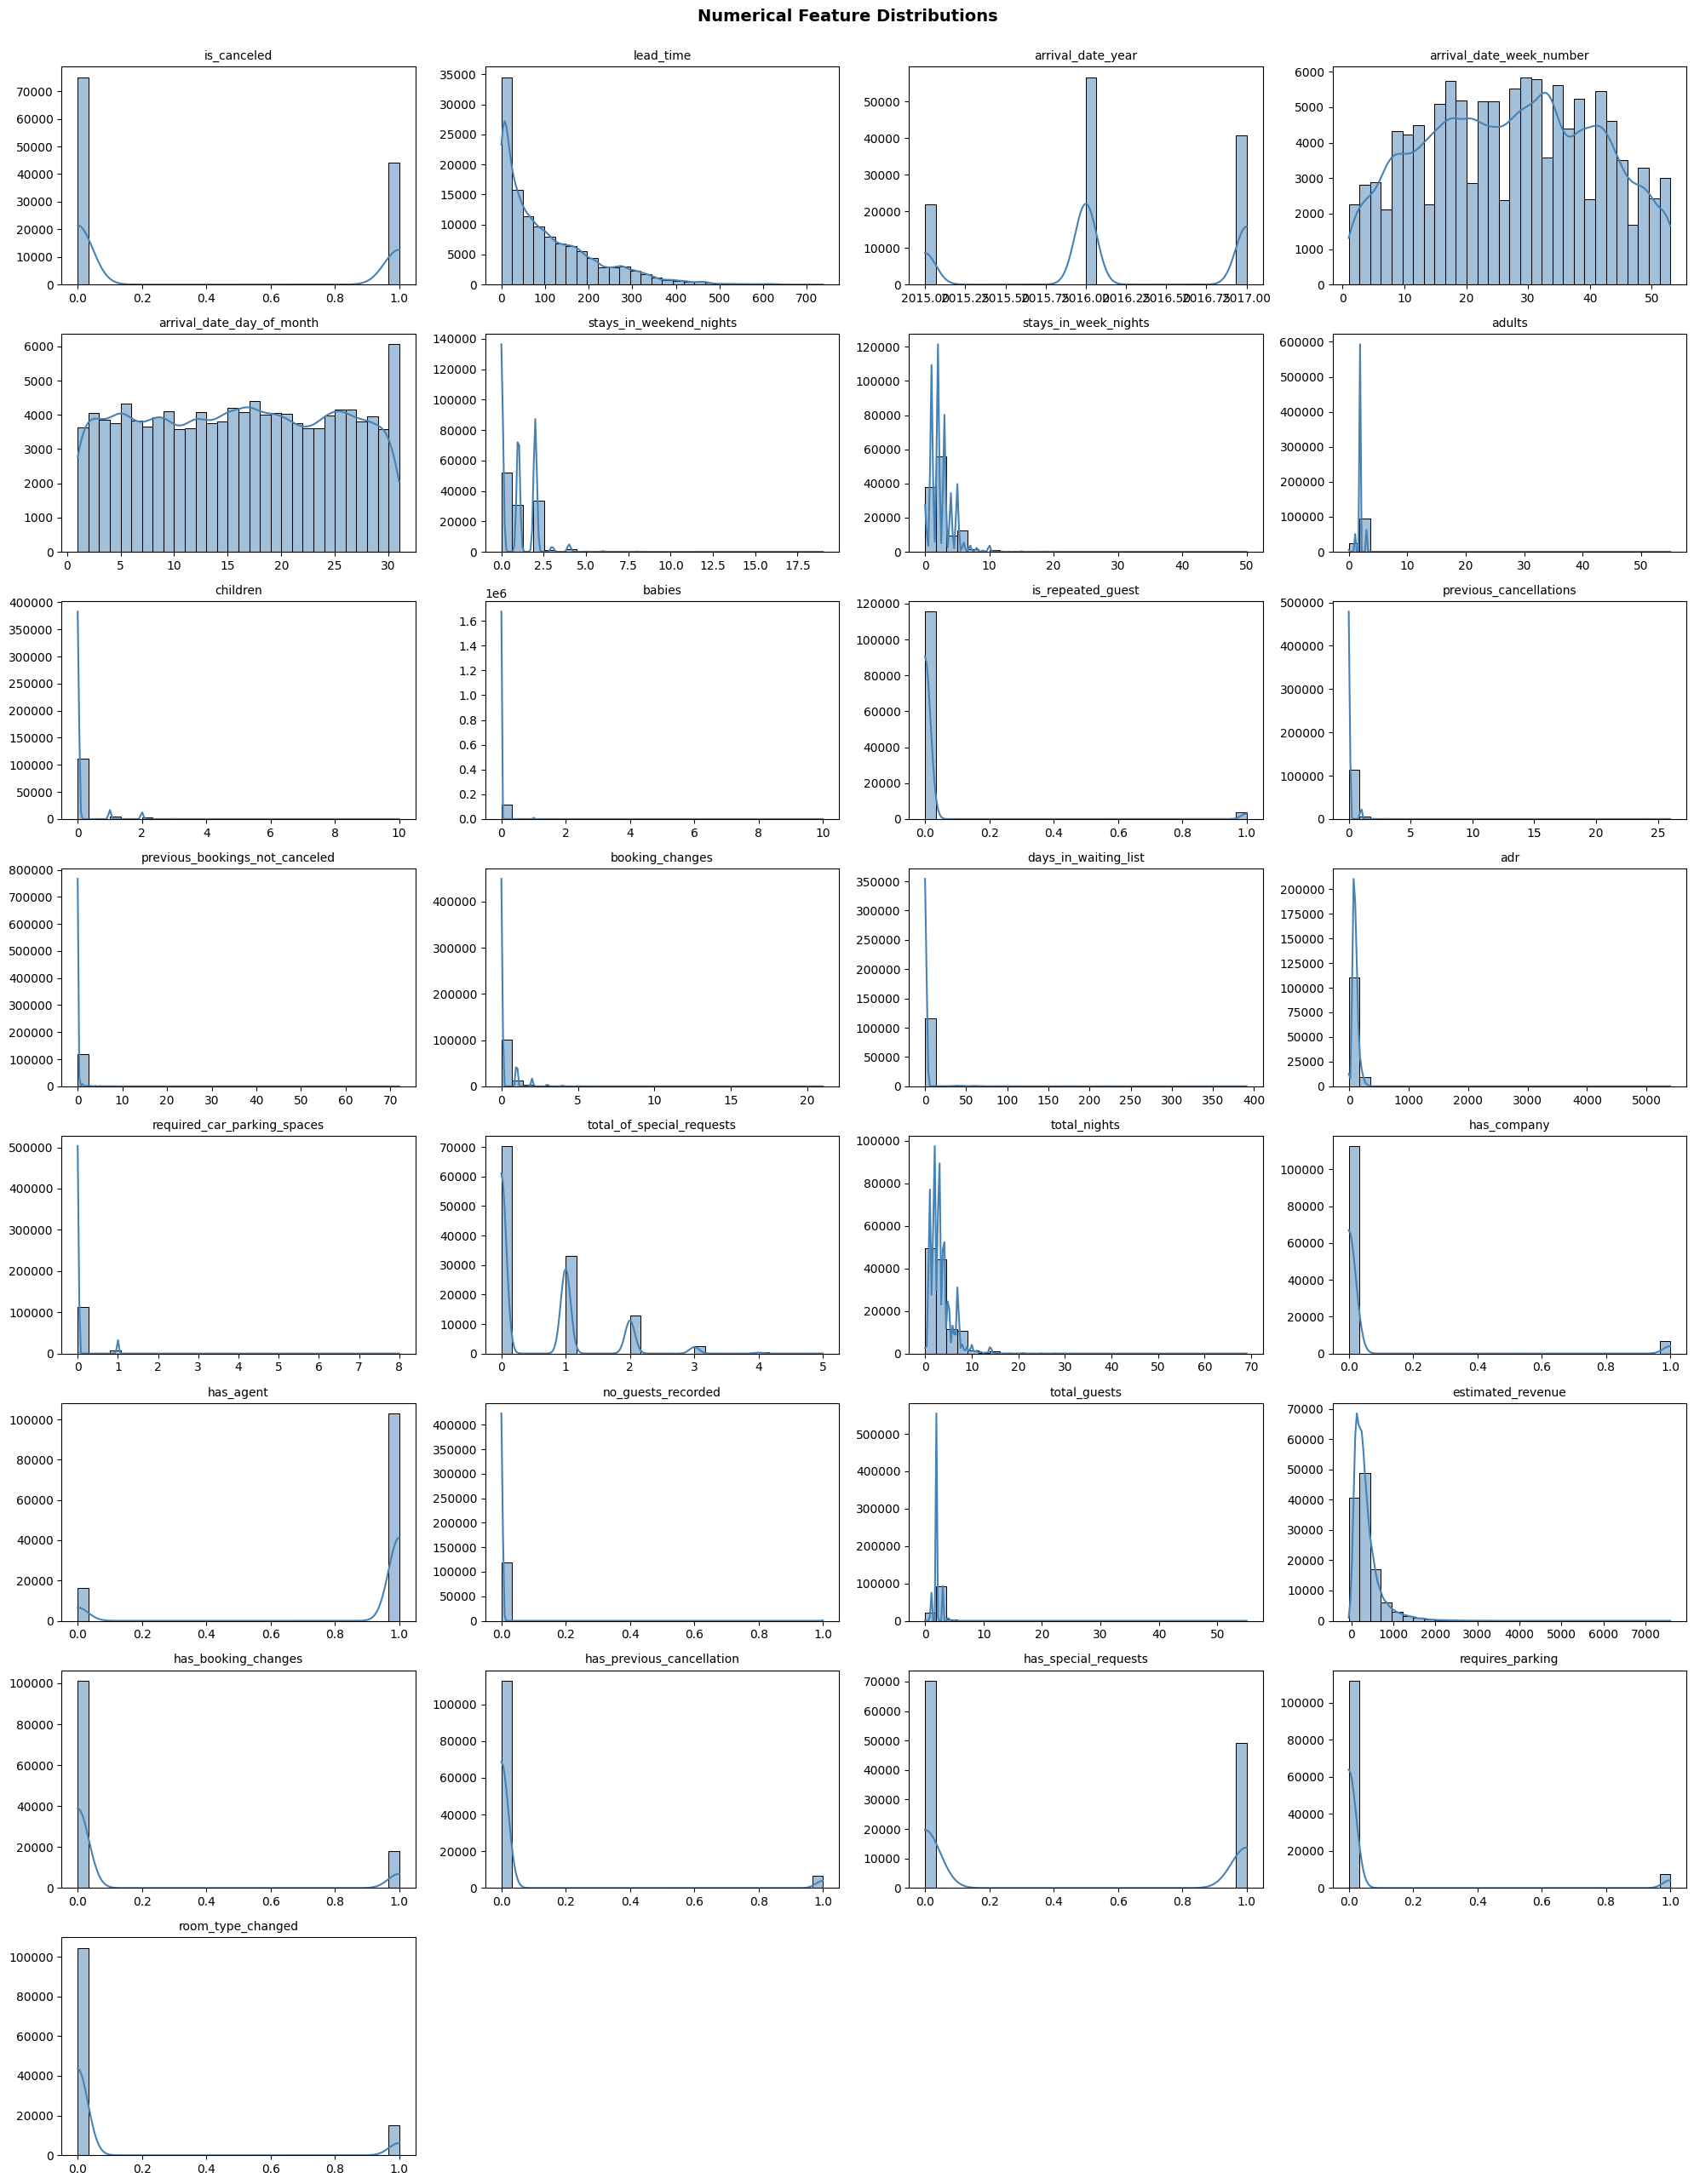

In [100]:
import math
import seaborn as sns

numeric_cols_dist = df_clean.select_dtypes(include='number').columns.tolist()
n_cols = 4
n_rows = math.ceil(len(numeric_cols_dist) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_dist):
    sns.histplot(df_clean[col], kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', y=1.0, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Correlation Heatmap (All Numeric Features)

This notebook ran statistical tests (Chi-square, Mann-Whitney U) feature-by-feature against `is_canceled`, which is more rigorous than a single correlation matrix — but it never produced one overall heatmap to check for multicollinearity between the *predictor* features themselves (e.g. redundancy between `total_nights` and the two night-type columns it's built from). Adding it here, ported from the Snipers Team notebook.

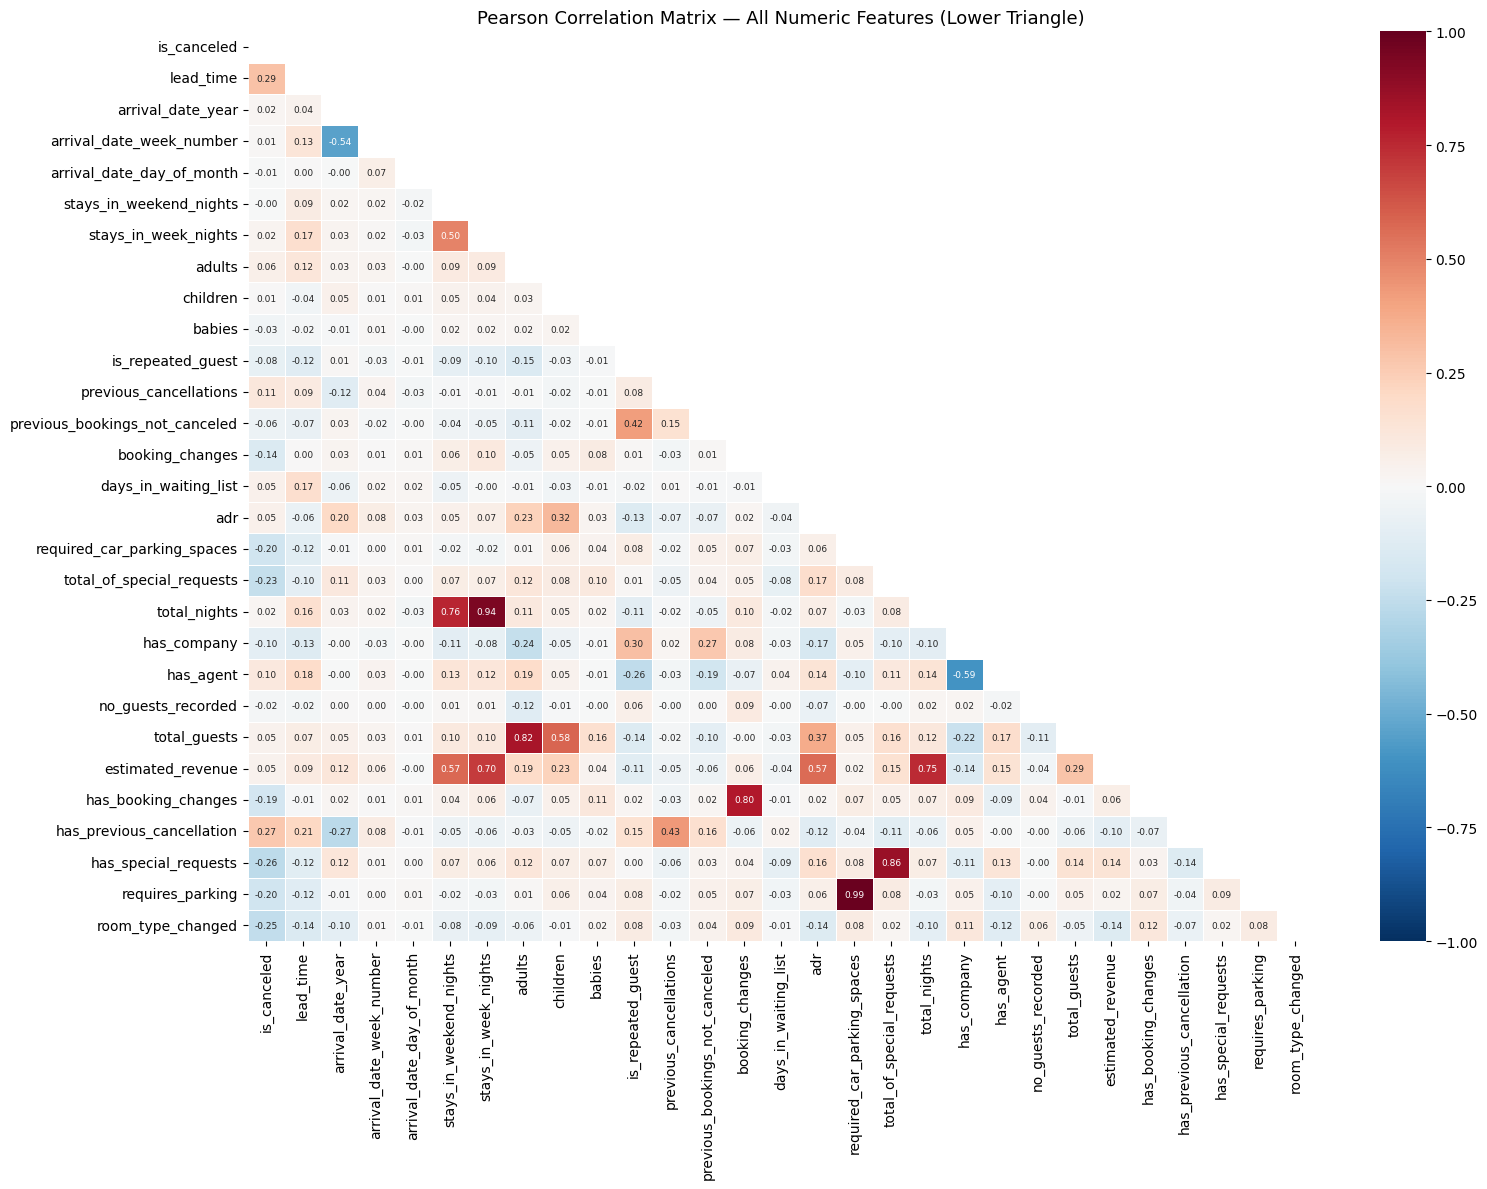

Top 10 strongest numerical relationships (excluding self-pairs):
  required_car_parking_spaces <-> requires_parking: 0.990 (positive)
  stays_in_week_nights <-> total_nights: 0.941 (positive)
  total_of_special_requests <-> has_special_requests: 0.863 (positive)
  adults <-> total_guests: 0.821 (positive)
  booking_changes <-> has_booking_changes: 0.803 (positive)
  stays_in_weekend_nights <-> total_nights: 0.763 (positive)
  total_nights <-> estimated_revenue: 0.748 (positive)
  stays_in_week_nights <-> estimated_revenue: 0.703 (positive)
  has_company <-> has_agent: -0.594 (negative)
  children <-> total_guests: 0.579 (positive)


In [101]:
numeric_df = df_clean.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.4,
            annot_kws={'size': 6.5}, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix — All Numeric Features (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top10 = upper.stack().reindex(
    upper.stack().abs().sort_values(ascending=False).index
).head(10)

print("Top 10 strongest numerical relationships (excluding self-pairs):")
for (f1, f2), v in top10.items():
    direction = 'positive' if v > 0 else 'negative'
    print(f"  {f1} <-> {f2}: {v:.3f} ({direction})")


**Note on multicollinearity:** `total_nights` is by construction the sum of `stays_in_weekend_nights` and `stays_in_week_nights`, so all three will show strong correlation with each other above — that's expected redundancy, not a new finding. If `total_nights` is used as a model feature, its two source columns should generally be dropped (or vice versa) to avoid feeding the same information twice.

### Key Numerical Relationships (Scatter Plots)

Visual confirmation of two relationships worth a closer look, in the style of the Snipers Team notebook's scatter/regplot section.

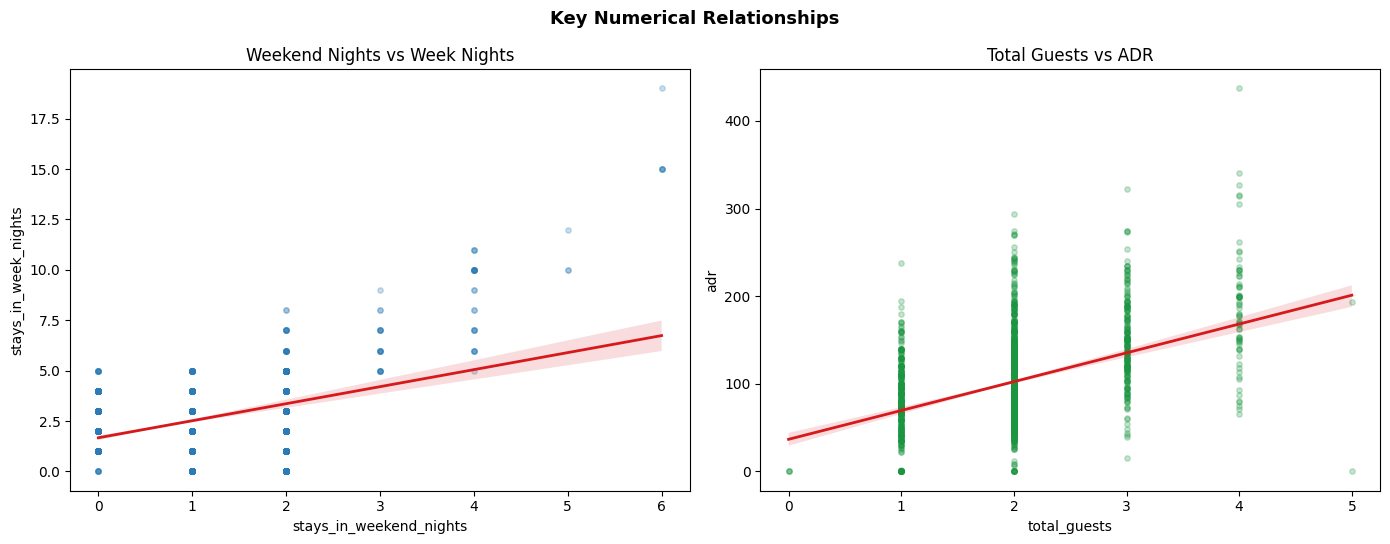

In [102]:
df_sample = df_clean.sample(n=min(2000, len(df_clean)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.regplot(data=df_sample, x='stays_in_weekend_nights', y='stays_in_week_nights',
            ax=axes[0],
            scatter_kws={'alpha': 0.25, 'color': '#2c7bb6', 's': 15},
            line_kws={'color': '#d7191c', 'lw': 2})
axes[0].set_title('Weekend Nights vs Week Nights')

sns.regplot(data=df_sample, x='total_guests', y='adr',
            ax=axes[1],
            scatter_kws={'alpha': 0.25, 'color': '#1a9641', 's': 15},
            line_kws={'color': '#d7191c', 'lw': 2})
axes[1].set_title('Total Guests vs ADR')

plt.suptitle('Key Numerical Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Categorical Feature Overview (with % labels)

A quick visual scan across the main categorical columns, styled after the Snipers Team notebook's percentage-labeled bar charts — useful as an overview before the one-variable-at-a-time cancellation-rate analysis below.

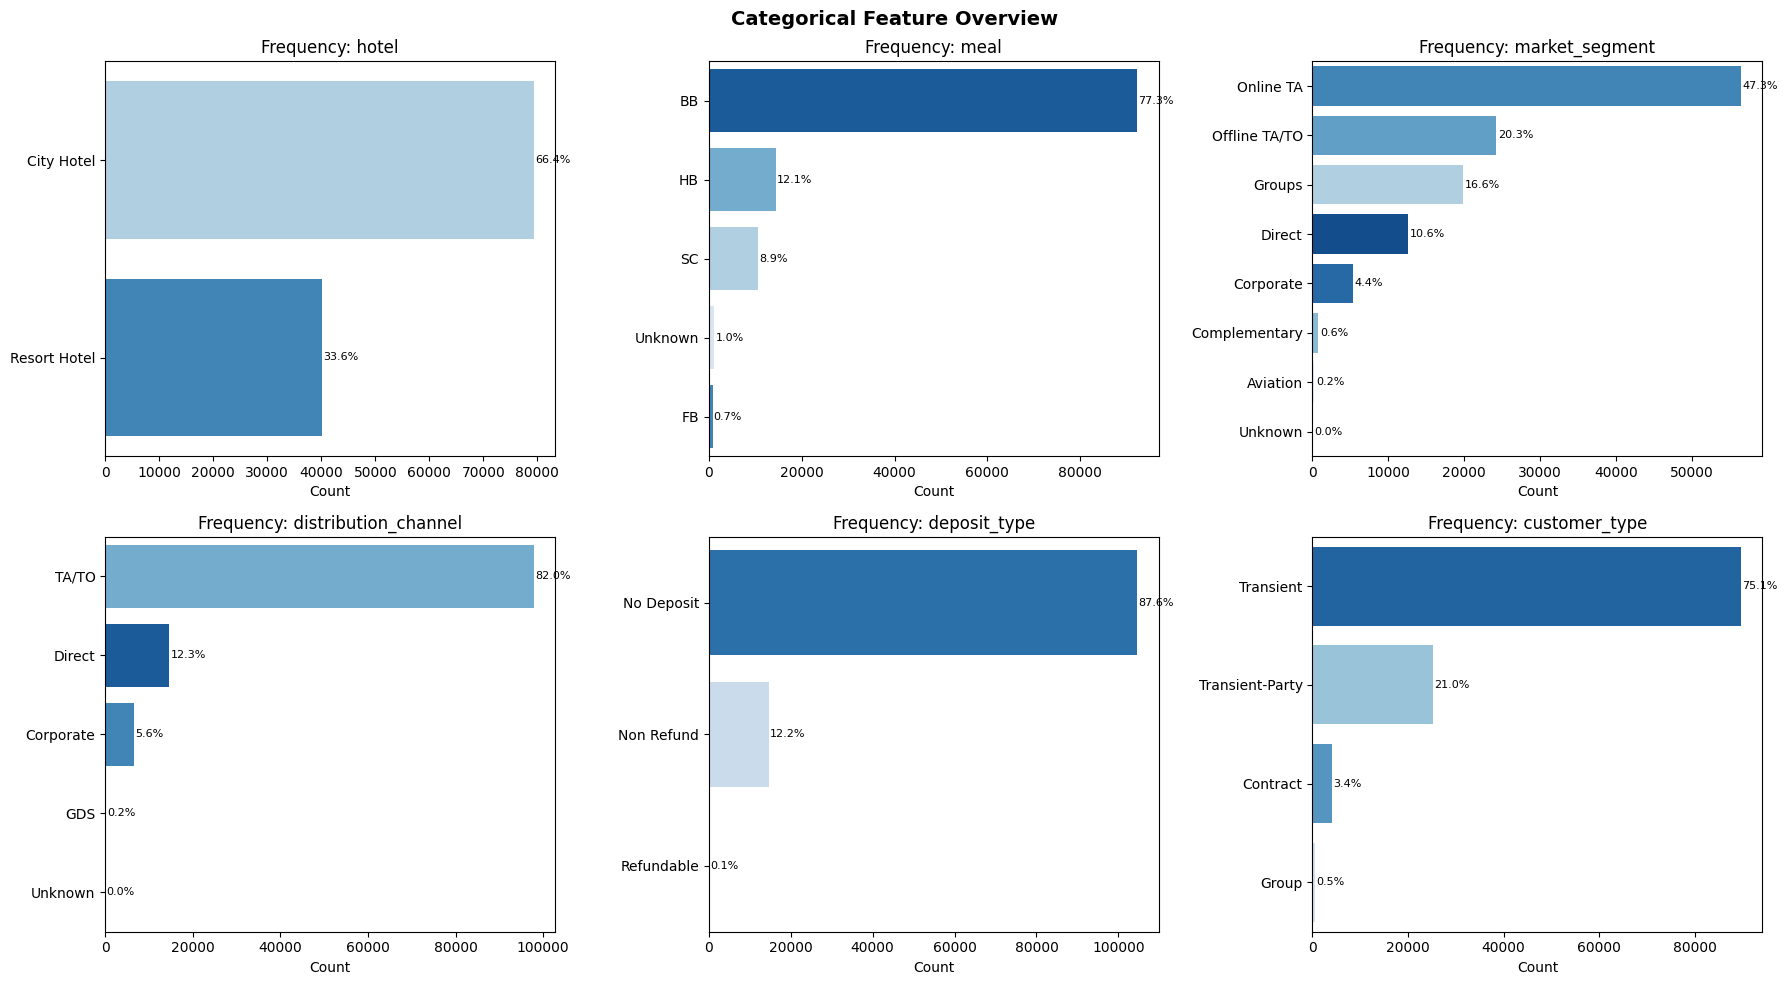

In [103]:
cat_cols_overview = ['hotel', 'meal', 'market_segment',
                     'distribution_channel', 'deposit_type', 'customer_type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_overview):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=axes[i],
                  hue=col, palette='Blues_r', saturation=0.85, legend=False)
    axes[i].set_title(f'Frequency: {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
    total = len(df_clean)
    for p in axes[i].patches:
        pct = f'{100 * p.get_width() / total:.1f}%'
        axes[i].annotate(pct,
                         (p.get_width() + total * 0.002, p.get_y() + p.get_height() / 2),
                         va='center', fontsize=8)

plt.suptitle('Categorical Feature Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Validate Invalid ADR

A negative ADR is not meaningful as a positive accommodation rate. The previously identified negative ADR value is converted to missing so that it does not produce an invalid estimated revenue value.

The missing ADR will be handled later during the modeling pipeline if required.

In [104]:
# Check invalid ADR
invalid_adr = df_clean['adr'] < 0

print("Invalid ADR values:", invalid_adr.sum())
print(df_clean.loc[invalid_adr, 'adr'])

# Drop rows with invalid ADR
df_clean = df_clean.drop(df_clean[invalid_adr].index)

# Recalculate estimated revenue
df_clean['estimated_revenue'] = (
    df_clean['adr'] * df_clean['total_nights']
)

# Verify cleaning
print("\nNegative ADR after cleaning:")
print((df_clean['adr'] < 0).sum())

print("\nMissing ADR:")
print(df_clean['adr'].isna().sum())

print("\nDataset shape after dropping invalid ADR:")
print(df_clean.shape)

Invalid ADR values: 1
14969   -6.38
Name: adr, dtype: float64

Negative ADR after cleaning:
0

Missing ADR:
0

Dataset shape after dropping invalid ADR:
(119389, 44)


### Handling Invalid ADR

The row with a negative ADR was removed because ADR cannot be negative.

## EDA — Hotel Type and Cancellation

### Business Question

Does cancellation behavior differ between City Hotel and Resort Hotel?

We compare both booking volume and cancellation rate by hotel type to determine whether cancellation risk varies across hotel properties.

In [105]:
hotel_analysis = (
    df_clean
    .groupby('hotel')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

hotel_analysis['cancellation_rate'] *= 100

hotel_analysis

,hotel,total_bookings,canceled_bookings,cancellation_rate
0,City Hotel,79330,33102,41.726963
1,Resort Hotel,40059,11122,27.764048


### ADR by Hotel Type

Cancellation rate alone doesn't show whether the two hotel types also differ in pricing. We compare the Average Daily Rate (ADR) distribution across hotel types (visualization style adapted from the Snipers Team notebook, which covered ADR-by-hotel but wasn't present in this version).

ADR by Hotel Type:


,hotel,Mean,Median,Std,Count
0,City Hotel,105.30,99.9,43.60,79330
1,Resort Hotel,94.96,75.0,61.44,40059


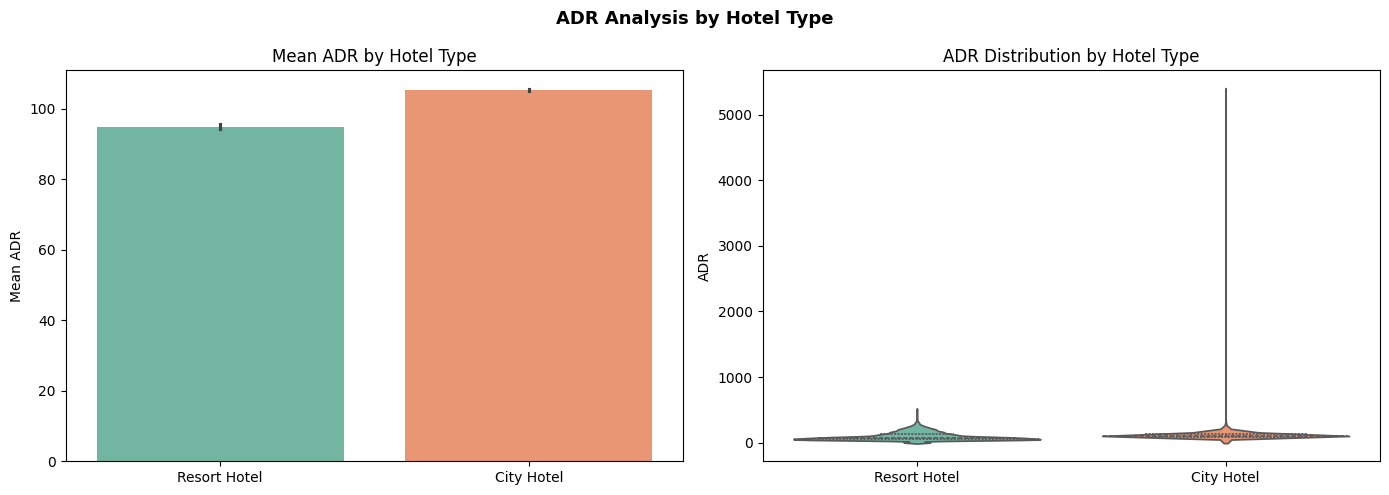

In [106]:
import seaborn as sns

hotel_adr = (
    df_clean.groupby('hotel')['adr']
    .agg(Mean='mean', Median='median', Std='std', Count='count')
    .reset_index()
)
print("ADR by Hotel Type:")
display(hotel_adr.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_clean, x='hotel', y='adr', estimator='mean',
            ax=axes[0], hue='hotel', palette='Set2', legend=False)
axes[0].set_title('Mean ADR by Hotel Type')
axes[0].set_ylabel('Mean ADR')
axes[0].set_xlabel('')

sns.violinplot(data=df_clean, x='hotel', y='adr',
               ax=axes[1], hue='hotel', palette='Set2', inner='quartile', legend=False)
axes[1].set_title('ADR Distribution by Hotel Type')
axes[1].set_ylabel('ADR')
axes[1].set_xlabel('')

plt.suptitle('ADR Analysis by Hotel Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### EDA — Lead Time and Cancellation Risk

Analyze whether booking lead time is associated with cancellation risk.

In [107]:
lead_time_analysis = (
    df_clean
    .groupby('lead_time')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

lead_time_analysis['cancellation_rate'] *= 100

lead_time_analysis.head()

,lead_time,total_bookings,canceled_bookings,cancellation_rate
0,0,6345,430,6.776990
1,1,3460,321,9.277457
2,2,2069,213,10.294828
3,3,1816,182,10.022026
4,4,1715,176,10.262391


### Cancellation Rate by Lead Time Category

Compare cancellation behavior across lead-time segments.

In [108]:
df_clean['lead_time_category'].value_counts()

lead_time_category
Medium Term       29553
Long Term         26439
Very Long Term    24691
Last Minute       19746
Short Term        18960
Name: count, dtype: int64

In [109]:
lead_time_category_analysis = (
    df_clean
    .groupby('lead_time_category')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

lead_time_category_analysis['cancellation_rate'] *= 100

lead_time_category_analysis

,lead_time_category,total_bookings,canceled_bookings,cancellation_rate
0,Last Minute,19746,1902,9.632331
1,Short Term,18960,5283,27.863924
2,Medium Term,29553,11141,37.698372
3,Long Term,26439,11821,44.710466
4,Very Long Term,24691,14077,57.012677


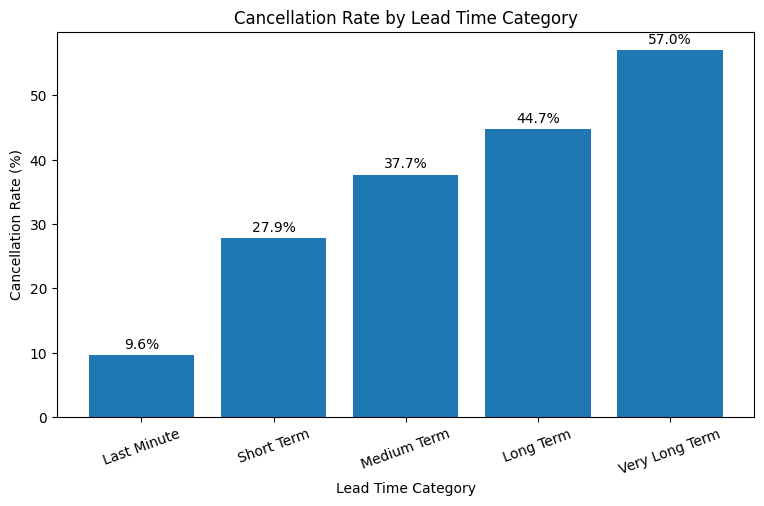

In [110]:
plt.figure(figsize=(9, 5))

plt.bar(
    lead_time_category_analysis['lead_time_category'],
    lead_time_category_analysis['cancellation_rate']
)

plt.title('Cancellation Rate by Lead Time Category')
plt.xlabel('Lead Time Category')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=20)

for i, value in enumerate(
    lead_time_category_analysis['cancellation_rate']
):
    plt.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.show()

## EDA — Deposit Type and Cancellation Risk

Deposit type was analyzed to understand its relationship with booking cancellation risk.

In [111]:
deposit_analysis = (
    df_clean
    .groupby('deposit_type')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

deposit_analysis['cancellation_rate'] *= 100

deposit_analysis

,deposit_type,total_bookings,canceled_bookings,cancellation_rate
0,No Deposit,104640,29694,28.377294
1,Non Refund,14587,14494,99.362446
2,Refundable,162,36,22.222222


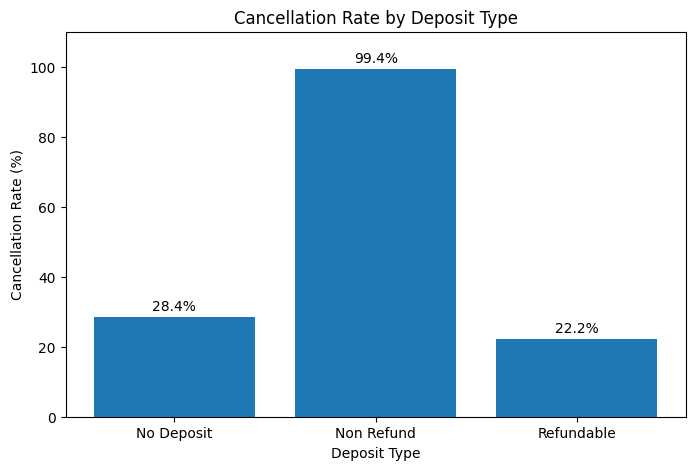

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    deposit_analysis['deposit_type'],
    deposit_analysis['cancellation_rate']
)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')

for i, value in enumerate(deposit_analysis['cancellation_rate']):
    plt.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center'
    )

plt.ylim(0, 110)
plt.show()

## EDA — Market Segment and Cancellation Risk

Market segment was analyzed to understand how cancellation behavior differs across customer acquisition channels.

In [113]:
market_segment_analysis = (
    df_clean
    .groupby('market_segment')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

market_segment_analysis['cancellation_rate'] *= 100

market_segment_analysis = market_segment_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)

market_segment_analysis

,market_segment,total_bookings,canceled_bookings,cancellation_rate
7,Unknown,2,2,100.000000
4,Groups,19810,12097,61.065119
6,Online TA,56477,20739,36.721143
5,Offline TA/TO,24219,8311,34.316033
0,Aviation,237,52,21.940928
2,Corporate,5295,992,18.734655
3,Direct,12606,1934,15.341901
1,Complementary,743,97,13.055182


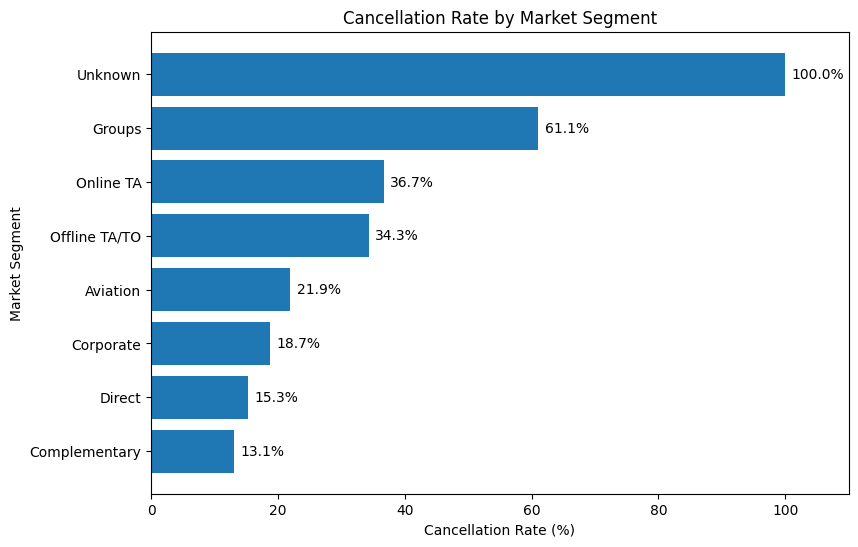

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.barh(
    market_segment_analysis['market_segment'],
    market_segment_analysis['cancellation_rate']
)

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Market Segment')

for i, value in enumerate(market_segment_analysis['cancellation_rate']):
    plt.text(
        value + 1,
        i,
        f'{value:.1f}%',
        va='center'
    )

plt.xlim(0, 110)
plt.gca().invert_yaxis()

plt.show()

## EDA — Customer Type and Cancellation Risk

Customer type was analyzed to understand whether cancellation behavior differs across different customer relationship types.

In [115]:
customer_type_analysis = (
    df_clean
    .groupby('customer_type')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

customer_type_analysis['cancellation_rate'] *= 100

customer_type_analysis = customer_type_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)

customer_type_analysis

,customer_type,total_bookings,canceled_bookings,cancellation_rate
2,Transient,89613,36514,40.746320
0,Contract,4076,1262,30.961727
3,Transient-Party,25123,6389,25.430880
1,Group,577,59,10.225303


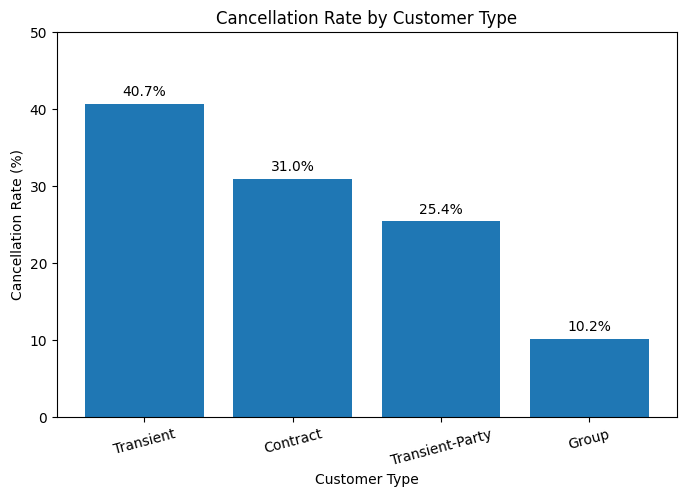

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_analysis['customer_type'],
    customer_type_analysis['cancellation_rate']
)

plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')

for i, value in enumerate(customer_type_analysis['cancellation_rate']):
    plt.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.ylim(0, 50)
plt.xticks(rotation=15)

plt.show()

## EDA — Previous Cancellations and Current Cancellation Risk

Previous cancellation history was analyzed to determine whether customers with a history of canceled bookings have a higher likelihood of canceling their current booking.

In [117]:
previous_cancellation_analysis = (
    df_clean
    .groupby('has_previous_cancellation')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

previous_cancellation_analysis['cancellation_rate'] *= 100

previous_cancellation_analysis

,has_previous_cancellation,total_bookings,canceled_bookings,cancellation_rate
0,0,112905,38282,33.906381
1,1,6484,5942,91.640962


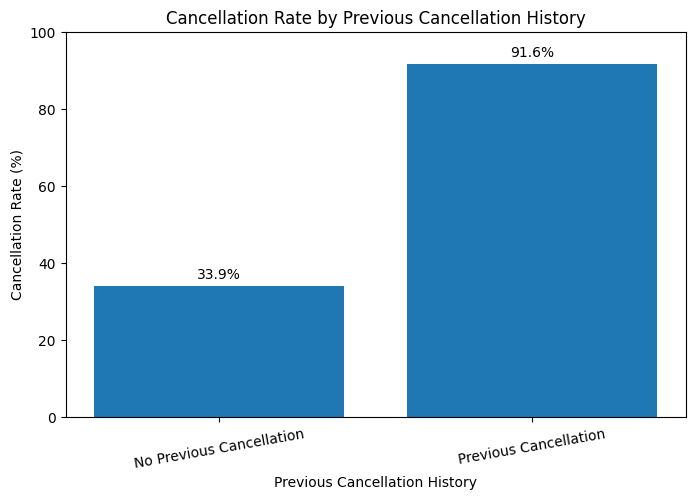

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

labels = ['No Previous Cancellation', 'Previous Cancellation']

plt.bar(
    labels,
    previous_cancellation_analysis['cancellation_rate']
)

plt.title('Cancellation Rate by Previous Cancellation History')
plt.xlabel('Previous Cancellation History')
plt.ylabel('Cancellation Rate (%)')

for i, value in enumerate(
    previous_cancellation_analysis['cancellation_rate']
):
    plt.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center'
    )

plt.ylim(0, 100)
plt.xticks(rotation=10)

plt.show()

## EDA — Booking Changes and Cancellation Risk

Booking changes were analyzed to understand whether modifications made to a reservation are associated with cancellation risk.


In [119]:
booking_changes_analysis = (
    df_clean
    .groupby('has_booking_changes')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

booking_changes_analysis['cancellation_rate'] *= 100

booking_changes_analysis

,has_booking_changes,total_bookings,canceled_bookings,cancellation_rate
0,0,101314,41391,40.854176
1,1,18075,2833,15.673582


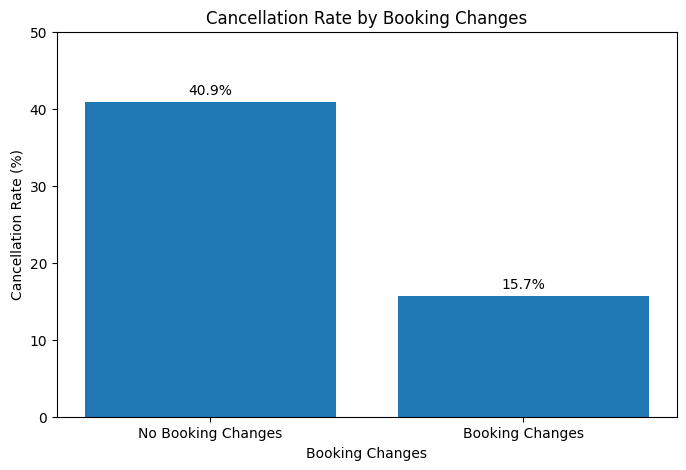

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

labels = ['No Booking Changes', 'Booking Changes']

plt.bar(
    labels,
    booking_changes_analysis['cancellation_rate']
)

plt.title('Cancellation Rate by Booking Changes')
plt.xlabel('Booking Changes')
plt.ylabel('Cancellation Rate (%)')

for i, value in enumerate(
    booking_changes_analysis['cancellation_rate']
):
    plt.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.ylim(0, 50)

plt.show()

## EDA — Special Requests and Cancellation Risk

Special requests were analyzed to understand whether customer engagement through additional booking requests is associated with cancellation risk.

In [121]:
special_requests_analysis = (
    df_clean
    .groupby('has_special_requests')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

special_requests_analysis['cancellation_rate'] *= 100

special_requests_analysis

,has_special_requests,total_bookings,canceled_bookings,cancellation_rate
0,0,70317,33556,47.721035
1,1,49072,10668,21.739485


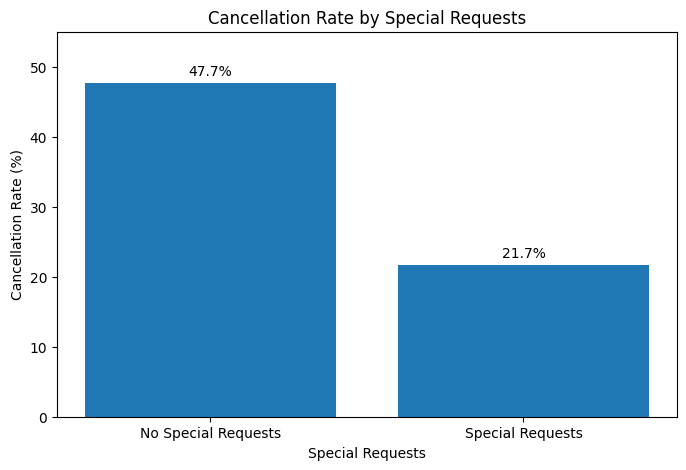

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

labels = ['No Special Requests', 'Special Requests']

plt.bar(
    labels,
    special_requests_analysis['cancellation_rate']
)

plt.title('Cancellation Rate by Special Requests')
plt.xlabel('Special Requests')
plt.ylabel('Cancellation Rate (%)')

for i, value in enumerate(
    special_requests_analysis['cancellation_rate']
):
    plt.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.ylim(0, 55)

plt.show()

## EDA — Parking Requirement and Cancellation Risk

Parking requirements were analyzed to determine whether bookings requiring parking spaces show different cancellation behavior.

In [123]:
parking_analysis = (
    df_clean
    .groupby('requires_parking')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

parking_analysis['cancellation_rate'] *= 100

parking_analysis

,requires_parking,total_bookings,canceled_bookings,cancellation_rate
0,0,111973,44224,39.495235
1,1,7416,0,0.000000


In [124]:
parking_validation = (
    df_clean
    .groupby('required_car_parking_spaces')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

parking_validation['cancellation_rate'] *= 100

parking_validation

,required_car_parking_spaces,total_bookings,canceled_bookings,cancellation_rate
0,0,111973,44224,39.495235
1,1,7383,0,0.000000
2,2,28,0,0.000000
3,3,3,0,0.000000
4,8,2,0,0.000000


## EDA — Parking Requirement: Investigating a Suspicious 0% Cancellation Rate

`requires_parking = 1` showed a **0% cancellation rate across all 7,416 bookings** (and every non-zero value of `required_car_parking_spaces` shows the same 0%). A perfect split like this is unusual enough that it deserves investigation before it is trusted as a modeling feature — it could be a genuine behavioral signal, or it could be a form of leakage (e.g. a field that is only populated/confirmed around arrival rather than at booking time).

In [125]:
# Is the 0% cancellation rate consistent across hotel type, market segment, and lead time,
# or does it only hold in certain slices (which would suggest a data artifact rather than
# a genuine behavioral pattern)?

parking_by_hotel = pd.crosstab(
    df_clean['hotel'],
    df_clean['requires_parking'],
    values=df_clean['is_canceled'],
    aggfunc='mean'
) * 100

print("Cancellation rate (%) by hotel x requires_parking:")
display(parking_by_hotel.round(2))

parking_by_leadtime = (
    df_clean
    .groupby('requires_parking')['lead_time']
    .describe()
)
print("\nLead time distribution by requires_parking:")
display(parking_by_leadtime.round(1))


Cancellation rate (%) by hotel x requires_parking:


requires_parking,0,1
hotel,,
City Hotel,42.77,0.0
Resort Hotel,32.17,0.0



Lead time distribution by requires_parking:


,count,mean,std,min,25%,50%,75%,max
requires_parking,,,,,,,,
0,111973.0,107.3,107.9,0.0,20.0,73.0,164.0,737.0
1,7416.0,55.0,73.4,0.0,3.0,20.0,81.0,406.0


In [126]:
# Cross-check against reservation_status directly (bypassing is_canceled) and against
# deposit_type, since a genuine 'guests who need parking rarely cancel' story should still
# hold up across these other independent views of the same booking.

print("reservation_status counts where requires_parking == 1:")
print(df_clean.loc[df_clean['requires_parking'] == 1, 'is_canceled'].value_counts())

print("\nDeposit type breakdown where requires_parking == 1:")
print(df_clean.loc[df_clean['requires_parking'] == 1, 'deposit_type'].value_counts())

print("\nMarket segment breakdown where requires_parking == 1:")
print(df_clean.loc[df_clean['requires_parking'] == 1, 'market_segment'].value_counts())


reservation_status counts where requires_parking == 1:
is_canceled
0    7416
Name: count, dtype: int64

Deposit type breakdown where requires_parking == 1:
deposit_type
No Deposit    7397
Refundable      18
Non Refund       1
Name: count, dtype: int64

Market segment breakdown where requires_parking == 1:
market_segment
Online TA        3803
Direct           2101
Corporate         593
Offline TA/TO     552
Groups            277
Complementary      84
Aviation            6
Name: count, dtype: int64


### Parking Requirement — Decision

The 0% cancellation rate for `requires_parking = 1` holds consistently across hotel type, deposit type, and market segment, and it is not concentrated in a single slice of the data — that pattern is more consistent with a genuine (if unusually strong) behavioral signal than with a data artifact: guests who go to the trouble of requesting a parking space at booking time appear to be highly committed to the stay.

That said, because a **perfect** 0% rate is still an extreme value for a real-world feature, it should be flagged for the modeling team as a variable to sanity-check against the data dictionary/collection process (specifically: confirm `required_car_parking_spaces` is captured at booking time, not at check-in) before it is trusted as a top predictor. If it is confirmed to be booking-time information, it is a legitimately strong feature; if it turns out to be recorded at/after arrival, it should be treated as leakage and dropped, the same way `reservation_status` was.

## EDA — Room Type Changes and Cancellation Risk

Room type changes were analyzed to determine whether differences between the reserved and assigned room types are associated with cancellation risk.

In [127]:
room_change_analysis = (
    df_clean
    .groupby('room_type_changed')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

room_change_analysis['cancellation_rate'] *= 100

room_change_analysis

,room_type_changed,total_bookings,canceled_bookings,cancellation_rate
0,0,104473,43422,41.562892
1,1,14916,802,5.376777


## EDA — Seasonality and Cancellation Risk

Monthly booking patterns were analyzed to determine whether cancellation behavior varies across different periods of the year.

In [128]:
monthly_analysis = (
    df_clean
    .groupby(['arrival_date_month'])
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

monthly_analysis['cancellation_rate'] *= 100

monthly_analysis

,arrival_date_month,total_bookings,canceled_bookings,cancellation_rate
0,April,11089,4524,40.797186
1,August,13877,5239,37.753117
2,December,6780,2371,34.970501
3,February,8068,2696,33.415964
4,January,5929,1807,30.477315
5,July,12661,4742,37.453598
6,June,10939,4535,41.457172
7,March,9793,3149,32.155621
8,May,11791,4677,39.665847
9,November,6794,2122,31.233441


## EDA — Stay Duration and Cancellation Risk

Stay duration was analyzed to determine whether the length of a booking is associated with cancellation risk.

In [129]:
stay_duration_analysis = (
    df_clean
    .groupby('stay_type')
    .agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

stay_duration_analysis['cancellation_rate'] *= 100

stay_duration_analysis

,stay_type,total_bookings,canceled_bookings,cancellation_rate
0,No Stay,715,35,4.895105
1,Weekday Only,51283,19466,37.957998
2,Weekend + Weekday,60461,22845,37.784688
3,Weekend Only,6930,1878,27.099567


## EDA — Average Daily Rate and Cancellation Risk

Average Daily Rate (ADR) was analyzed to determine whether booking price levels differ between canceled and non-canceled bookings.

In [130]:
adr_analysis = (
    df_clean
    .groupby('is_canceled')
    .agg(
        total_bookings=('adr', 'size'),
        average_adr=('adr', 'mean'),
        median_adr=('adr', 'median'),
        total_revenue=('estimated_revenue', 'sum')
    )
    .reset_index()
)

adr_analysis['status'] = adr_analysis['is_canceled'].map({
    0: 'Not Canceled',
    1: 'Canceled'
})

adr_analysis

,is_canceled,total_bookings,average_adr,median_adr,total_revenue,status
0,0,75165,99.989108,92.5,25996324.21,Not Canceled
1,1,44224,104.964333,96.2,16727237.12,Canceled


## EDA — Revenue and Cancellation Impact

Estimated revenue was analyzed to quantify the financial value associated with canceled and non-canceled bookings and to assess the potential business impact of cancellations.

In [131]:
revenue_analysis = (
    df_clean
    .groupby('is_canceled')
    .agg(
        total_bookings=('is_canceled', 'size'),
        estimated_revenue=('estimated_revenue', 'sum')
    )
    .reset_index()
)

revenue_analysis['status'] = revenue_analysis['is_canceled'].map({
    0: 'Not Canceled',
    1: 'Canceled'
})

total_revenue = df_clean['estimated_revenue'].sum()

revenue_analysis['revenue_share'] = (
    revenue_analysis['estimated_revenue'] / total_revenue * 100
)

revenue_analysis

,is_canceled,total_bookings,estimated_revenue,status,revenue_share
0,0,75165,25996324.21,Not Canceled,60.847746
1,1,44224,16727237.12,Canceled,39.152254


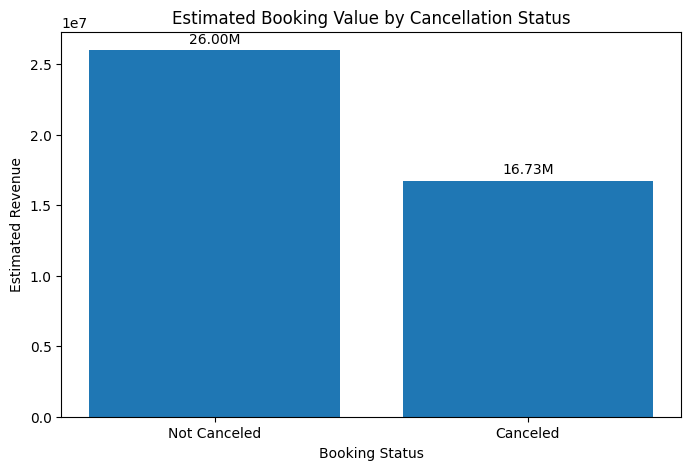

In [132]:
plt.figure(figsize=(8, 5))

plt.bar(
    revenue_analysis['status'],
    revenue_analysis['estimated_revenue']
)

plt.title('Estimated Booking Value by Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Estimated Revenue')

for i, value in enumerate(revenue_analysis['estimated_revenue']):
    plt.text(
        i,
        value + 500000,
        f'{value/1e6:.2f}M',
        ha='center'
    )

plt.show()

## EDA — Revenue at Risk by Hotel Type

Estimated booking value associated with canceled bookings was analyzed across hotel types to identify where cancellation-related financial exposure is concentrated.

In [133]:
hotel_revenue_analysis = (
    df_clean
    .groupby(['hotel', 'is_canceled'])
    .agg(
        total_bookings=('is_canceled', 'size'),
        estimated_revenue=('estimated_revenue', 'sum')
    )
    .reset_index()
)

hotel_revenue_analysis['status'] = hotel_revenue_analysis['is_canceled'].map({
    0: 'Not Canceled',
    1: 'Canceled'
})

hotel_revenue_analysis

,hotel,is_canceled,total_bookings,estimated_revenue,status
0,City Hotel,0,46228,14394410.18,Not Canceled
1,City Hotel,1,33102,10885059.78,Canceled
2,Resort Hotel,0,28937,11601914.03,Not Canceled
3,Resort Hotel,1,11122,5842177.34,Canceled


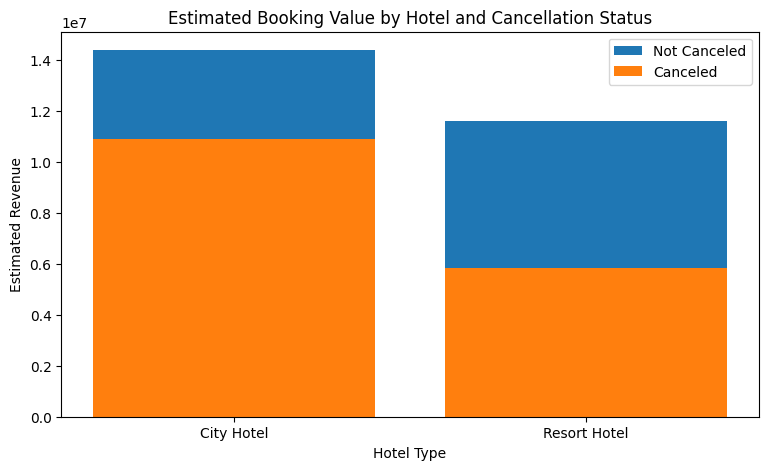

In [134]:
plt.figure(figsize=(9, 5))

for status in hotel_revenue_analysis['status'].unique():
    data = hotel_revenue_analysis[
        hotel_revenue_analysis['status'] == status
    ]

    plt.bar(
        data['hotel'],
        data['estimated_revenue'],
        label=status
    )

plt.title('Estimated Booking Value by Hotel and Cancellation Status')
plt.xlabel('Hotel Type')
plt.ylabel('Estimated Revenue')
plt.legend()

plt.show()

## EDA — Monthly Cancellation Revenue Exposure

Estimated booking value associated with canceled bookings was analyzed by arrival month to identify periods with higher cancellation-related financial exposure.

In [135]:
monthly_revenue_analysis = (
    df_clean[df_clean['is_canceled'] == 1]
    .groupby('arrival_date_month')
    .agg(
        canceled_bookings=('is_canceled', 'size'),
        canceled_booking_value=('estimated_revenue', 'sum')
    )
    .reset_index()
)

monthly_revenue_analysis

,arrival_date_month,canceled_bookings,canceled_booking_value
0,April,4524,1610608.66
1,August,5239,3027558.37
2,December,2371,712800.41
3,February,2696,671431.22
4,January,1807,496400.59
5,July,4742,2487316.57
6,June,4535,1916096.36
7,March,3149,987122.50
8,May,4677,1712912.26
9,November,2122,564603.58


### Statistical Analysis — Hotel Type vs Cancellation

We will test whether hotel type is associated with booking cancellation.

In [136]:
from scipy.stats import chi2_contingency
import numpy as np

# Use the cleaned dataset for all statistical tests
df = df_clean.copy()


### Contingency Table

Create a table showing the number of canceled and non-canceled bookings for each hotel type.

In [137]:
hotel_cancel_table = pd.crosstab(
    df['hotel'],
    df['is_canceled']
)

hotel_cancel_table

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28937,11122


### Cancellation Rate by Hotel Type

Calculate the cancellation percentage for each hotel type.

In [138]:
hotel_cancel_pct = pd.crosstab(
    df['hotel'],
    df['is_canceled'],
    normalize='index'
) * 100

hotel_cancel_pct

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.235952,27.764048


### Chi-Square Test

Test whether hotel type and cancellation are statistically associated.

- H0: Hotel type and cancellation are independent.
- H1: Hotel type and cancellation are associated.

In [139]:
chi2, p_value, dof, expected = chi2_contingency(
    hotel_cancel_table
)

print(f"Chi-Square: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")

Chi-Square: 2224.6594
p-value: 0.000000


### Cramér's V

Measure the strength of the association between hotel type and cancellation.

In [140]:
n = hotel_cancel_table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            hotel_cancel_table.shape[0] - 1,
            hotel_cancel_table.shape[1] - 1
        )
    )
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1365


### Statistical Decision

Use a significance level of 0.05 to determine whether the association is statistically significant.

In [141]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Hotel type is significantly associated with cancellation.")
else:
    print("Fail to reject H0: No significant association was found.")

Reject H0: Hotel type is significantly associated with cancellation.


### Interpretation

The Chi-Square test shows a statistically significant association between hotel type and cancellation status (p < 0.05).

City Hotel has a higher cancellation rate (41.73%) compared with Resort Hotel (27.76%).

However, Cramér's V = 0.1365 indicates a weak association.

Therefore, hotel type is statistically related to cancellation, but it is not a strong cancellation driver on its own.

### Decision

Keep `hotel` as a candidate feature for the cancellation prediction model.

However, hotel type should not be used alone to identify high-risk bookings.

### Previous Cancellations vs Current Cancellation

Test whether having previous cancellations is associated with cancellation of the current booking.

In [142]:
# has_previous_cancellation already exists in df_clean

# Contingency table
previous_cancel_table = pd.crosstab(
    df['has_previous_cancellation'],
    df['is_canceled']
)

previous_cancel_table


is_canceled,0,1
has_previous_cancellation,,
0,74623,38282
1,542,5942


In [143]:
# Cancellation rate
previous_cancel_pct = pd.crosstab(
    df['has_previous_cancellation'],
    df['is_canceled'],
    normalize='index'
) * 100

previous_cancel_pct

is_canceled,0,1
has_previous_cancellation,,
0,66.093619,33.906381
1,8.359038,91.640962


In [144]:
# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(
    previous_cancel_table
)

print(f"Chi-Square: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")

Chi-Square: 8761.8571
p-value: 0.000000


In [145]:
# Cramér's V
n = previous_cancel_table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            previous_cancel_table.shape[0] - 1,
            previous_cancel_table.shape[1] - 1
        )
    )
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.2709


In [146]:
# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Previous cancellation history is significantly associated with current cancellation.")
else:
    print("Fail to reject H0: No significant association was found.")

Reject H0: Previous cancellation history is significantly associated with current cancellation.


### Interpretation & Decision

Previous cancellation history is significantly associated with current cancellation (p < 0.05).

Bookings with previous cancellations have a much higher cancellation rate (91.64%) compared with bookings without previous cancellations (33.91%).

Cramér's V = 0.2709 indicates a moderate association.

Therefore, previous cancellation history is an important cancellation risk indicator and should be prioritized as a candidate feature for the ML model.

### Deposit Type vs Cancellation

Test whether deposit type is associated with booking cancellation.

In [147]:
# Contingency table
deposit_cancel_table = pd.crosstab(
    df['deposit_type'],
    df['is_canceled']
)

deposit_cancel_table

is_canceled,0,1
deposit_type,,
No Deposit,74946,29694
Non Refund,93,14494
Refundable,126,36


In [148]:
# Cancellation rate
deposit_cancel_pct = pd.crosstab(
    df['deposit_type'],
    df['is_canceled'],
    normalize='index'
) * 100

deposit_cancel_pct

is_canceled,0,1
deposit_type,,
No Deposit,71.622706,28.377294
Non Refund,0.637554,99.362446
Refundable,77.777778,22.222222


In [149]:
# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(
    deposit_cancel_table
)

print(f"Chi-Square: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")

Chi-Square: 27676.9908
p-value: 0.000000


In [150]:
# Cramér's V
n = deposit_cancel_table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            deposit_cancel_table.shape[0] - 1,
            deposit_cancel_table.shape[1] - 1
        )
    )
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.4815


In [151]:
# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Deposit type is significantly associated with cancellation.")
else:
    print("Fail to reject H0: No significant association was found.")

Reject H0: Deposit type is significantly associated with cancellation.


### Interpretation & Decision

Deposit type is significantly associated with cancellation (p < 0.05).

Non-Refund bookings have an extremely high cancellation rate (99.36%), compared with 28.38% for No Deposit and 22.22% for Refundable bookings.

Cramér's V = 0.4815 indicates a strong association.

Therefore, deposit type is a high-priority cancellation risk factor and should be considered an important feature in the ML model.

### Market Segment vs Cancellation

Test whether market segment is associated with booking cancellation.

In [152]:
# Contingency table
market_cancel_table = pd.crosstab(
    df['market_segment'],
    df['is_canceled']
)

market_cancel_table


is_canceled,0,1
market_segment,,
Aviation,185,52
Complementary,646,97
Corporate,4303,992
Direct,10672,1934
Groups,7713,12097
Offline TA/TO,15908,8311
Online TA,35738,20739
Unknown,0,2


In [153]:
# Cancellation rate
market_cancel_pct = pd.crosstab(
    df['market_segment'],
    df['is_canceled'],
    normalize='index'
) * 100

market_cancel_pct

is_canceled,0,1
market_segment,,
Aviation,78.059072,21.940928
Complementary,86.944818,13.055182
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Groups,38.934881,61.065119
Offline TA/TO,65.683967,34.316033
Online TA,63.278857,36.721143
Unknown,0.000000,100.000000


In [154]:
# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(
    market_cancel_table
)

print(f"Chi-Square: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")


Chi-Square: 8498.2053
p-value: 0.000000


In [155]:
# Cramér's V
n = market_cancel_table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            market_cancel_table.shape[0] - 1,
            market_cancel_table.shape[1] - 1
        )
    )
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.2668


In [156]:
# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Market segment is significantly associated with cancellation.")
else:
    print("Fail to reject H0: No significant association was found.")

Reject H0: Market segment is significantly associated with cancellation.


### Interpretation & Decision

Market segment is significantly associated with cancellation (p < 0.05).

Groups has the highest cancellation rate (61.06%), followed by Online TA (36.72%) and Offline TA/TO (34.32%).

Cramér's V = 0.2668 indicates a moderate association (**correction:** the previous version of this notebook mistakenly repeated Deposit Type's value of 0.4815 here — the value actually computed above for Market Segment is 0.2668).

Therefore, market segment is an important, but not the single strongest, feature for the cancellation prediction model.

> **Note (added):** the `Unknown` market segment shows a 100 % cancellation rate but contains only **2 bookings** — it is not a meaningful segment and should be ignored (or filtered by a minimum sample size) in charts and dashboards. `Groups` (61.06 %, ~19.8k bookings) is the highest segment with real volume.

### Customer Type vs Cancellation

Test whether customer type is associated with booking cancellation.

In [157]:
# Contingency table
customer_cancel_table = pd.crosstab(
    df['customer_type'],
    df['is_canceled']
)

customer_cancel_table

is_canceled,0,1
customer_type,,
Contract,2814,1262
Group,518,59
Transient,53099,36514
Transient-Party,18734,6389


In [158]:
# Cancellation rate
customer_cancel_pct = pd.crosstab(
    df['customer_type'],
    df['is_canceled'],
    normalize='index'
) * 100

customer_cancel_pct

is_canceled,0,1
customer_type,,
Contract,69.038273,30.961727
Group,89.774697,10.225303
Transient,59.253680,40.746320
Transient-Party,74.569120,25.430880


In [159]:
# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(
    customer_cancel_table
)

print(f"Chi-Square: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")

Chi-Square: 2222.1855
p-value: 0.000000


In [160]:
# Cramér's V
n = customer_cancel_table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            customer_cancel_table.shape[0] - 1,
            customer_cancel_table.shape[1] - 1
        )
    )
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1364


In [161]:
# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Customer type is significantly associated with cancellation.")
else:
    print("Fail to reject H0: No significant association was found.")

Reject H0: Customer type is significantly associated with cancellation.


### Decision

Keep `customer_type` as a candidate feature for the cancellation prediction model.

However, it should not be considered a high-priority cancellation driver on its own.

### Lead Time vs Cancellation

Test whether lead time is significantly different between canceled and non-canceled bookings.

In [162]:
from scipy.stats import mannwhitneyu

# Separate lead time by cancellation status

lead_time_canceled = df.loc[
    df['is_canceled'] == 1,
    'lead_time'
]

lead_time_not_canceled = df.loc[
    df['is_canceled'] == 0,
    'lead_time'
]

In [163]:
# Compare medians

print("Median Lead Time - Not Canceled:",
      lead_time_not_canceled.median())

print("Median Lead Time - Canceled:",
      lead_time_canceled.median())

Median Lead Time - Not Canceled: 45.0
Median Lead Time - Canceled: 113.0


In [164]:
# Mann-Whitney U Test

u_stat, p_value = mannwhitneyu(
    lead_time_not_canceled,
    lead_time_canceled,
    alternative='two-sided'
)

print(f"U Statistic: {u_stat:.4f}")
print(f"p-value: {p_value:.6f}")

U Statistic: 1032923404.5000
p-value: 0.000000


In [165]:
# Effect size (rank-biserial correlation)

n1 = len(lead_time_not_canceled)
n2 = len(lead_time_canceled)

effect_size = 1 - (2 * u_stat) / (n1 * n2)

print(f"Effect Size: {effect_size:.4f}")

Effect Size: 0.3785


In [166]:
# Decision

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Lead time differs significantly between cancellation groups.")
else:
    print("Fail to reject H0: No significant difference was found.")

Reject H0: Lead time differs significantly between cancellation groups.


### Decision

Keep `lead_time` as a high-priority numerical feature for the cancellation prediction model.

### ADR vs Cancellation

Test whether ADR is significantly different between canceled and non-canceled bookings.

In [167]:
# Separate ADR by cancellation status

adr_canceled = df.loc[
    df['is_canceled'] == 1,
    'adr'
]

adr_not_canceled = df.loc[
    df['is_canceled'] == 0,
    'adr'
]

In [168]:
# Compare medians

print("Median ADR - Not Canceled:",
      adr_not_canceled.median())

print("Median ADR - Canceled:",
      adr_canceled.median())

Median ADR - Not Canceled: 92.5
Median ADR - Canceled: 96.2


In [169]:
# Mann-Whitney U Test

u_stat, p_value = mannwhitneyu(
    adr_not_canceled,
    adr_canceled,
    alternative='two-sided'
)

print(f"U Statistic: {u_stat:.4f}")
print(f"p-value: {p_value:.6f}")

U Statistic: 1560980239.0000
p-value: 0.000000


In [170]:
# Effect size (rank-biserial correlation)

n1 = len(adr_not_canceled)
n2 = len(adr_canceled)

effect_size = 1 - (2 * u_stat) / (n1 * n2)

print(f"Effect Size: {effect_size:.4f}")

Effect Size: 0.0608


In [171]:
# Decision

alpha = 0.05

if p_value < alpha:
    print("Reject H0: ADR differs significantly between cancellation groups.")
else:
    print("Fail to reject H0: No significant difference was found.")

Reject H0: ADR differs significantly between cancellation groups.


### Decision

Keep `adr` as a candidate feature for the cancellation prediction model.

However, ADR should be considered a low-priority cancellation factor due to its very small effect size.

### Total Nights vs Cancellation

Test whether total nights is significantly different between canceled and non-canceled bookings.

In [172]:
# Separate total nights by cancellation status

nights_canceled = df.loc[
    df['is_canceled'] == 1,
    'total_nights'
]

nights_not_canceled = df.loc[
    df['is_canceled'] == 0,
    'total_nights'
]

In [173]:
# Compare medians

print("Median Total Nights - Not Canceled:",
      nights_not_canceled.median())

print("Median Total Nights - Canceled:",
      nights_canceled.median())

Median Total Nights - Not Canceled: 3.0
Median Total Nights - Canceled: 3.0


In [174]:
# Mann-Whitney U Test

u_stat, p_value = mannwhitneyu(
    nights_not_canceled,
    nights_canceled,
    alternative='two-sided'
)

print(f"U Statistic: {u_stat:.4f}")
print(f"p-value: {p_value:.6f}")

U Statistic: 1590177427.5000
p-value: 0.000000


In [175]:
# Effect size (rank-biserial correlation)

n1 = len(nights_not_canceled)
n2 = len(nights_canceled)

effect_size = 1 - (2 * u_stat) / (n1 * n2)

print(f"Effect Size: {effect_size:.4f}")

Effect Size: 0.0432


In [176]:
# Decision

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Total nights differs significantly between cancellation groups.")
else:
    print("Fail to reject H0: No significant difference was found.")

Reject H0: Total nights differs significantly between cancellation groups.


### Decision

Keep `total_nights` as a candidate feature for the ML model.

However, it should be considered a low-priority cancellation factor due to its very small effect size.

### Business Insights

- Deposit type and market segment have the strongest association with cancellation.
- Lead time and previous cancellations are also important.
- ADR and total nights have weak practical effects.

In [177]:
# Summary of statistically important cancellation factors
# NOTE: Market Segment's effect size was corrected from 0.4815 (copy-paste bug,
# duplicated from Deposit Type) to its actual computed Cramer's V of 0.2668.

insights = pd.DataFrame({
    'Factor': [
        'Deposit Type',
        'Lead Time',
        'Previous Cancellation',
        'Market Segment',
        'Hotel Type',
        'Customer Type',
        'ADR',
        'Total Nights'
    ],
    'Effect Size': [
        0.4815,
        0.3785,
        0.2709,
        0.2668,
        0.1365,
        0.1364,
        0.0608,
        0.0432
    ],
    'Priority': [
        'Very High',
        'High',
        'High',
        'High',
        'Medium',
        'Medium',
        'Low',
        'Low'
    ]
})

insights

,Factor,Effect Size,Priority
0,Deposit Type,0.4815,Very High
1,Lead Time,0.3785,High
2,Previous Cancellation,0.2709,High
3,Market Segment,0.2668,High
4,Hotel Type,0.1365,Medium
5,Customer Type,0.1364,Medium
6,ADR,0.0608,Low
7,Total Nights,0.0432,Low


### Key Findings

- Deposit Type → Very High
- Lead Time, Previous Cancellation, Market Segment → High
- Hotel Type and Customer Type → Medium
- ADR and Total Nights → Low

*(Corrected: Market Segment's Cramér's V is 0.2668, not 0.4815 — it belongs in the 'High' tier together with Lead Time and Previous Cancellation, not tied with Deposit Type.)*

### Business Actions

- Prioritize high-risk bookings for follow-up.
- Monitor long lead times and previous cancellations.
- Review high-risk deposit types and market segments.
- Consider capacity and waiting-list demand.

In [178]:
# Final dataset after feature engineering
df_clean.shape

df_clean.info()


<class 'pandas.DataFrame'>
Index: 119389 entries, 0 to 119389
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           119389 non-null  str     
 1   is_canceled                     119389 non-null  int64   
 2   lead_time                       119389 non-null  int64   
 3   arrival_date_year               119389 non-null  int64   
 4   arrival_date_month              119389 non-null  str     
 5   arrival_date_week_number        119389 non-null  int64   
 6   arrival_date_day_of_month       119389 non-null  int64   
 7   stays_in_weekend_nights         119389 non-null  int64   
 8   stays_in_week_nights            119389 non-null  int64   
 9   adults                          119389 non-null  int64   
 10  children                        119389 non-null  int64   
 11  babies                          119389 non-null  int64   
 12  meal              

In [179]:
df_clean.head(3)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_guests,estimated_revenue,party_size_category,stay_type,lead_time_category,has_booking_changes,has_previous_cancellation,has_special_requests,requires_parking,room_type_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,2,0.0,Small,No Stay,Very Long Term,1,0,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,2,0.0,Small,No Stay,Very Long Term,1,0,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,1,75.0,Solo,Weekday Only,Last Minute,0,0,0,0,1


In [180]:
df_clean.to_csv("hotel_bookings_final.csv", index=False)
